# 02_100m격자_보정인구_추정

### 100m 격자 인구 보정식

#### 1. 500m 기준 인구 잔차

$$
R_g = P^{500}_g - \sum_{i \in g} P_i
$$

- `R_g`: 500m 격자 g의 인구 잔차
- `P^{500}_g`: 500m 격자 g의 총인구수
- `P_i`: 100m 격자 i의 기존 총인구수

#### 2. 100m 격자별 배분 비중

$$
p_i = \frac{P_i}{\sum_{i \in g} P_i}, \quad
h_i = \frac{H_i}{\sum_{i \in g} H_i}, \quad
a_i = \frac{A_i}{\sum_{i \in g} A_i}
$$

- `p_i`: 500m 내부 기존 인구 비중
- `h_i`: 500m 내부 주택수 비중
- `a_i`: 500m 내부 주거면적 비중
- `H_i`: 100m 격자 i의 주택수
- `A_i`: 100m 격자 i의 주거면적

#### 3. 보정 지수 후보

$$
I_{1i} = h_i
$$

$$
I_{2i} = 0.3p_i + 0.7h_i
$$

$$
I_{3i} = 0.5p_i + 0.5h_i
$$

$$
I_{4i} = 0.3p_i + 0.5h_i + 0.2a_i
$$

- `I_{1i}`: 주택수 기반 지수
- `I_{2i}`: 기존 인구 30% + 주택수 70% 지수
- `I_{3i}`: 기존 인구 50% + 주택수 50% 지수
- `I_{4i}`: 기존 인구 30% + 주택수 50% + 주거면적 20% 지수

#### 4. 지수 정규화

$$
\tilde{I}_{ki} = \frac{I_{ki}}{\sum_{i \in g} I_{ki}}
$$

- `\tilde{I}_{ki}`: 정규화된 보정 지수
- `k`: 보정 지수 번호

#### 5. 최종 100m 추정인구수

$$
\hat{P}_{ki} = P_i + R_g \times \tilde{I}_{ki}
$$

- `\hat{P}_{ki}`: k번째 방식으로 보정한 100m 추정인구수

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pathlib
import numpy as np

BASE_PATH = pathlib.Path().resolve()

if BASE_PATH.name == "notebooks":
    BASE_PATH = BASE_PATH.parent
elif BASE_PATH.name != "analysis_table" and (BASE_PATH / "analysis_table").exists():
    BASE_PATH = BASE_PATH / "analysis_table"

INPUT_PATH = BASE_PATH / "data" / "input"
OUTPUT_PATH = BASE_PATH / "data" / "output"

DATA_PATH = INPUT_PATH
RAW_DATA = DATA_PATH / "raw"
PRO_DATA = OUTPUT_PATH

IMAGE_PATH = BASE_PATH / "image"
IMAGE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
MAKING_TABLE_PATH = OUTPUT_PATH


## 기본 데이터 불러오기

In [2]:
grid100 = gpd.read_file(PRO_DATA / "서울시_격자_100m_행정동_기본테이블.gpkg")

print(f"그리드 100 CRS: {grid100.crs}") # EPSG 5179
print(f"그리드 100 칼럼: {grid100.columns}") # GRID_CD, geometry
print(f"그리드 100 지오메트리 타입: {grid100.geometry.geom_type.unique()}") #polygon
print(f"그리드 100 레코드 수 : {len(grid100)}") # 824647개
display(grid100.head())


그리드 100 CRS: EPSG:5179
그리드 100 칼럼: Index(['GRID_CD', '행정동코드', '시군구', '행정동', '중심점_x', '중심점_y', 'geometry'], dtype='str')
그리드 100 지오메트리 타입: <StringArray>
['Polygon']
Length: 1, dtype: str
그리드 100 레코드 수 : 60528


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


### 100m 그리드 인구 데이터

In [3]:
GRID_PATH = DATA_PATH / "grid"

shp_list = list((GRID_PATH / "100M총인구").glob("*/vl_blk.shp"))
pop_list = []
for shp in shp_list:
    gu = shp.parent.name.strip()
    temp = gpd.read_file(shp, encoding='utf-8')
    temp["시군구"] = gu
    pop_list.append(temp)
    
pop100 = gpd.GeoDataFrame(
    pd.concat(pop_list,ignore_index=True),
    crs = pop_list[0].crs
)

pop100 = pop100.rename(
    columns = {
        "gid": "GRID_CD",
        "val": "총인구수"
    }
)



In [4]:
# 데이터 품질 확인
display(pop100.info())
print("="*100)
display(pop100.describe())
print("="*100)
print(f"pop100 crs: {pop100.crs}")
print("="*100)
print(f"pop100 geomtype: {pop100.geometry.geom_type.unique()}")
print("="*100)
print(f"pop100 결측치: {pop100.isna().sum()}")
print("="*100)
print(f"pop100 GRID_CD 중복값: {pop100["GRID_CD"].duplicated(keep=False).sum()}")
print(f"pop100 그리드코드x총인구수 중복값: {pop100[["GRID_CD", "총인구수"]].duplicated(keep=False).sum()}")

# ====================================================================================================
# pop100 crs: EPSG:5179
# ====================================================================================================
# pop100 geomtype: ['Polygon']
# ====================================================================================================
# pop100 결측치: 
# GRID_CD         0
# lbl         33279
# 총인구수        33279
# geometry        0
# 시군구             0
# dtype: int64
# ====================================================================================================
# pop100 GRID_CD 중복값: 6013
# pop100 그리드코드x총인구수 중복값: 3694

# 중복값: 같은 GRID_CD, 다른 구 소속 
# 하지만 GRID_CD가 같으면서 다른 중복값인 3029-1865 개만큼 레코드도 존재 -> 별도 점검 필요


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 64681 entries, 0 to 64680
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GRID_CD   64681 non-null  str     
 1   lbl       31402 non-null  str     
 2   총인구수      31402 non-null  float64 
 3   geometry  64681 non-null  geometry
 4   시군구       64681 non-null  str     
dtypes: float64(1), geometry(1), str(3)
memory usage: 2.5 MB


None

,총인구수
count,31402.000000
mean,297.194414
std,260.629702
min,0.000000
25%,98.000000
50%,263.000000
75%,430.000000
max,12522.000000


pop100 crs: EPSG:5179
pop100 geomtype: <StringArray>
['Polygon']
Length: 1, dtype: str
pop100 결측치: GRID_CD         0
lbl         33279
총인구수        33279
geometry        0
시군구             0
dtype: int64
pop100 GRID_CD 중복값: 6013
pop100 그리드코드x총인구수 중복값: 3694


In [5]:
# 결측값 처리
# 결측은 BSCA 노이즈로 인함. 따라서 0으로 채움
pop100_check = pop100.copy()
pop100_check["총인구수"] = pop100_check["총인구수"].fillna(0)


# 중복값 점검
print(f"총인구수: {pop100["총인구수"].sum()}") #9332499.0



# 그리드 코드 같으면서 geometry까지 중복인 같은 레코드
pop100_check.groupby("GRID_CD")["geometry"].nunique().value_counts()
# geometry
# 1    61652
# Name: count, dtype: int64
# 그리드랑 geometry 는 일대일 관계


# 부분중복: 그리드코드 같지만 총인구수 다른 중복 레코드
pop100_dup_check = pop100_check.groupby("GRID_CD")["총인구수"].nunique().reset_index(name = "레코드수")
pop100_dup_idx = pop100_dup_check[pop100_dup_check["레코드수"] > 1]["GRID_CD"]

pop100_dup = pop100_check[pop100_check["GRID_CD"].isin(pop100_dup_idx)]
display(pop100_dup.sort_values(by=["GRID_CD", "총인구수"]).head(50))
print(len(pop100_dup))
print(pop100_dup["GRID_CD"].nunique())


# 완전 중복: 그리드 코드 같고 총인구수도 같은 중복 레코드 
same_dup = pop100_check.groupby(by=["GRID_CD", "총인구수"]).size().reset_index(name = "완전중복수")


display(same_dup[(same_dup["완전중복수"]>1)&(same_dup["총인구수"]!=0)]) # 1개 나머지는 모두 인구수 0, "다사620505"만 총인구수 같음
pop100[pop100["GRID_CD"] == "다사620505"]

# 완전중복 의심 레코드 1개. 소수이며 앞의 대부분의 레코드는 부분 중복으로 집계되었으므로 위의 레코드 역시 우연히 총인구수가 같았을 가능성이 높다.
# 결론: 모든 중복치는 부분중복인 것으로 결정.


총인구수: 9332499.0


,GRID_CD,lbl,총인구수,geometry,시군구
11841,다사407495,NaN,0.0,"POLYGON ((940700 1949500, 940700 1949600, 9408...",강서구
49242,다사407495,206.00,206.0,"POLYGON ((940700 1949500, 940700 1949600, 9408...",양천구
11842,다사407496,NaN,0.0,"POLYGON ((940700 1949600, 940700 1949700, 9408...",강서구
49243,다사407496,419.00,419.0,"POLYGON ((940700 1949600, 940700 1949700, 9408...",양천구
49288,다사408493,193.00,193.0,"POLYGON ((940800 1949300, 940800 1949400, 9409...",양천구
11889,다사408493,232.00,232.0,"POLYGON ((940800 1949300, 940800 1949400, 9409...",강서구
49289,다사408494,NaN,0.0,"POLYGON ((940800 1949400, 940800 1949500, 9409...",양천구
11890,다사408494,90.00,90.0,"POLYGON ((940800 1949400, 940800 1949500, 9409...",강서구
49290,다사408495,NaN,0.0,"POLYGON ((940800 1949500, 940800 1949600, 9409...",양천구
11891,다사408495,606.00,606.0,"POLYGON ((940800 1949500, 940800 1949600, 9409...",강서구


2164
1077


,GRID_CD,총인구수,완전중복수
48853,다사620505,69.0,2


,GRID_CD,lbl,총인구수,geometry,시군구
17063,다사620505,69.00,69.0,"POLYGON ((962000 1950500, 962000 1950600, 9621...",광진구
42752,다사620505,69.00,69.0,"POLYGON ((962000 1950500, 962000 1950600, 9621...",성동구


In [6]:
# 중복치 처리
pop100_clean = pop100_check.groupby("GRID_CD", as_index=False)\
    .agg(
    {"총인구수": 'sum',
     "geometry": 'first'}
)

pop100_clean = gpd.GeoDataFrame(
    pop100_clean,
    geometry = "geometry",
    crs = pop100.crs
)

print(f'중복값 개수: {pop100_clean["GRID_CD"].duplicated().sum()}')
print(f'레코드 수 : {len(pop100_clean)}')
print(f'총인구수 : {pop100_clean["총인구수"].sum()}')
print(f'geometry type : {pop100_clean.geometry.geom_type.unique()}')
print(f'crs : {pop100_clean.crs}')

# [pop100]
# 성공 !
# 중복값 개수: 0
# 레코드 수 : 61652
# 총인구수 : 9332499.0
# geometry type : ['Polygon']
# crs : EPSG:5179

# [grid_100]
# 중복값 개수: 0
# 레코드 수 : 60528
# geometry type : ['Polygon']
# crs : EPSG:5179

# grid_100의 inner join(격자 중심지가 서울 행정동 경계에 within 하지 않으면 삭제처리)으로 인해 레코드 수가 맞지 안흠




중복값 개수: 0
레코드 수 : 61652
총인구수 : 9332499.0
geometry type : <StringArray>
['Polygon']
Length: 1, dtype: str
crs : EPSG:5179


In [7]:
# pop100과 총인구수 합치기
print(f'중복값 개수: {grid100["GRID_CD"].duplicated().sum()}')
print(f'레코드 수 : {len(grid100)}')
print(f'geometry type : {grid100.geometry.geom_type.unique()}')
print(f'crs : {grid100.crs}')


# grid100 기준 merge left (이미 형성된 테이블 기준으로)
grid100_pop = grid100.merge(
    pop100_clean[["GRID_CD", "총인구수"]],
    on = "GRID_CD",
    how = 'left'
)

print("merge 후 레코드 수:", len(grid100_pop))
print("GRID_CD 중복 수:", grid100_pop["GRID_CD"].duplicated().sum())
print("총인구수 결측 수:", grid100_pop["총인구수"].isna().sum())
print("총인구수 합계:", grid100_pop["총인구수"].sum())

# 중복값 개수: 0
# 레코드 수 : 60528
# geometry type : <StringArray>
# ['Polygon']
# Length: 1, dtype: str
# crs : EPSG:5179

# merge 후 레코드 수: 60528
# GRID_CD 중복 수: 0
# 총인구수 결측 수: 0
# 총인구수 합계: 9330963.0

# pop100_clean 전체 총인구수: 9,332,499명
# merge 후 총인구수: 9,330,963명
# 차이: 1,536명
# 해당 차이는 merge 시 grid 중심점 기준 서울 경계 바깥에 위치한 grid가 자동 제거된 결과로 보임
# 1536명으로 총 인구수 대비 적은 수로 영향 적을 것으로 예상


중복값 개수: 0
레코드 수 : 60528
geometry type : <StringArray>
['Polygon']
Length: 1, dtype: str
crs : EPSG:5179
merge 후 레코드 수: 60528
GRID_CD 중복 수: 0
총인구수 결측 수: 0
총인구수 합계: 9330963.0


## grid 500 인구수 추가 (BSCA 노이즈 보정)

In [8]:
# 파일 불러오기
GRID500_PATH = DATA_PATH / "grid" / "500M총인구"
grid500_list = list(GRID500_PATH.glob("*/vl_blk.shp"))
print(len(grid500_list)) #25개

# 파일 읽기 - 행단위로 list에 저장
df_list = []
for shp in grid500_list:
    result = gpd.read_file(shp, encoding='utf-8')
    result["시군구"] = shp.parent.name
    df_list.append(result)

# 읽은 파일 gdf로 만들기
pop500 = gpd.GeoDataFrame(
    pd.concat(df_list, ignore_index=True),
    geometry = "geometry",
    crs = df_list[0].crs
)

print(f"500m 래스터 crs: {pop500.crs}")
print("="*100)
print(f"500m 래스터 데이터수 {len(pop500)}")
print("="*100)
print(f"500m 래스터 칼럼 {pop500.columns}") 
print("="*100)
print(f"500m 래스터 geomtype {pop500.geometry.geom_type.unique()}") 
print("="*100)
print(pop500.isna().sum()) 
display(pop500.head())
print("="*100)
display(pop500.info())
print("="*100)
display(pop500.describe(include='all'))

# 500m 래스터 crs: EPSG:5179
# ====================================================================================================
# 500m 래스터 데이터수 3227
# ====================================================================================================
# 500m 래스터 칼럼 Index(['gid', 'lbl', 'val', 'geometry', '시군구'], dtype='str')
# ====================================================================================================
# 500m 래스터 geomtype <StringArray>
# ['Polygon']
# Length: 1, dtype: str
# ====================================================================================================
# gid           0
# lbl         928
# val         928
# geometry      0
# 시군구           0


# 칼럼 변경
pop500 = pop500.rename(
    columns = {
        "gid": "GRID_CD_500",
        "val": "총인구수_500"
    }
)

# 칼럼드랍
pop500 = pop500.drop(columns = ["lbl"])


25
500m 래스터 crs: EPSG:5179
500m 래스터 데이터수 3227
500m 래스터 칼럼 Index(['gid', 'lbl', 'val', 'geometry', '시군구'], dtype='str')
500m 래스터 geomtype <StringArray>
['Polygon']
Length: 1, dtype: str
gid           0
lbl         928
val         928
geometry      0
시군구           0
dtype: int64


,gid,lbl,val,geometry,시군구
0,다사62b43b,8475.00,8475.0,"POLYGON ((962500 1943500, 962500 1944000, 9630...",강남구
1,다사62a42b,3709.00,3709.0,"POLYGON ((962000 1942500, 962000 1943000, 9625...",강남구
2,다사58b44a,6362.00,6362.0,"POLYGON ((958500 1944000, 958500 1944500, 9590...",강남구
3,다사60a42b,3086.00,3086.0,"POLYGON ((960000 1942500, 960000 1943000, 9605...",강남구
4,다사58a44a,1279.00,1279.0,"POLYGON ((958000 1944000, 958000 1944500, 9585...",강남구


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3227 entries, 0 to 3226
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   gid       3227 non-null   str     
 1   lbl       2299 non-null   str     
 2   val       2299 non-null   float64 
 3   geometry  3227 non-null   geometry
 4   시군구       3227 non-null   str     
dtypes: float64(1), geometry(1), str(3)
memory usage: 126.2 KB


None

,gid,lbl,val,geometry,시군구
count,3227,2299,2299.000000,3227,3227
unique,2634,1908,NaN,2634,25
top,다사47a43a,N/A,NaN,"POLYGON ((947000 1943000, 947000 1943500, 9475...",서초구
freq,4,118,NaN,4,238
mean,NaN,NaN,4061.185298,NaN,NaN
std,NaN,NaN,3431.040491,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,830.500000,NaN,NaN
50%,NaN,NaN,3430.000000,NaN,NaN
75%,NaN,NaN,6798.500000,NaN,NaN


### 결측치 처리
: BSCA 노이즈 혹은 제공되지 않는 통계 -> 0으로 처리

In [9]:
print(f"결측행 개수: {pop500.isna().any(axis=1).sum()}")
print(f"총인구수 결측행 개수: {pop500["총인구수_500"].isna().sum()}")
display(pop500[(pop500.isna()).any(axis=1)])
# 결측행 개수: 928
# 총인구수 결측행 개수: 928

pop500_notna = pop500.copy()
pop500_notna["총인구수_500"] = pop500_notna["총인구수_500"].fillna(0)
print(f"결측치 처리 확인: {pop500_notna["총인구수_500"].isna().sum()}")
# 결측치 처리 확인: 0


결측행 개수: 928
총인구수 결측행 개수: 928


,GRID_CD_500,총인구수_500,geometry,시군구
154,다사61a41a,NaN,"POLYGON ((961000 1941000, 961000 1941500, 9615...",강남구
155,다사60a48a,NaN,"POLYGON ((960000 1948000, 960000 1948500, 9605...",강남구
156,다사64a39b,NaN,"POLYGON ((964000 1939500, 964000 1940000, 9645...",강남구
157,다사64a44a,NaN,"POLYGON ((964000 1944000, 964000 1944500, 9645...",강남구
158,다사57b48a,NaN,"POLYGON ((957500 1948000, 957500 1948500, 9580...",강남구
...,...,...,...,...
3222,다사66a56b,NaN,"POLYGON ((966000 1956500, 966000 1957000, 9665...",중랑구
3223,다사62a57b,NaN,"POLYGON ((962000 1957500, 962000 1958000, 9625...",중랑구
3224,다사65b55a,NaN,"POLYGON ((965500 1955000, 965500 1955500, 9660...",중랑구
3225,다사66a57a,NaN,"POLYGON ((966000 1957000, 966000 1957500, 9665...",중랑구


결측치 처리 확인: 0


### 중복값 확인

In [10]:
# 전체 중복
print(f"전체중복: {pop500_notna.duplicated().sum()}")
# 전체중복: 0

# GRIDCODE 중복
print(f"코드 중복: {pop500_notna["GRID_CD_500"].duplicated().sum()}")
grid_dup = pop500_notna["GRID_CD_500"].duplicated(keep=False)
display(pop500_notna[grid_dup].sort_values(by=["GRID_CD_500", "총인구수_500"]).head(50))
# 코드 중복: 593

# GRIDCODE x geometry 확인
grid_geo_dup = pop500_notna.groupby("GRID_CD_500")["geometry"].nunique().reset_index(name="레코드수")
print(f"그리드 별 레코드수 : {grid_geo_dup.value_counts("레코드수")}")
#그리드 별 레코드수 : 레코드수 1    2634, 그리드내 상이한 geometry 없음

# GRIDCODE x 총인구수 확인
print(
    f"코드 x 총인구수 중복: {pop500_notna.duplicated(["GRID_CD_500", "총인구수_500"])
    .sum()}"
    )
# 코드 x 총인구수 중복: 140

grid_pop_dup = pop500_notna.groupby(
    by = "GRID_CD_500"
)["총인구수_500"].nunique().reset_index(name="레코드수")

grid_pop_idx = grid_pop_dup[
    grid_pop_dup["레코드수"]>1
    ]

display(
    pop500_notna[
        pop500_notna["GRID_CD_500"]
                 .isin(grid_pop_idx["GRID_CD_500"])]
                 .sort_values(
                     ["GRID_CD_500", "총인구수_500"]
                     )
                 .head(50)
    )

# 서로 다른 구에 같은 격자가 다수 들어있으며
# 해당 격자는 구마다 서로 다른 인구수 통계를 가지고 있다.
# 이는 구 경계에 걸쳐 있는 같은 격자에 대해 격자를 공유하는 서로 다른 구마다 통계를 분리해서 집계한 결과로 보임(100m 격자와 동일)
# 결론: GRID_CD_500 기준으로 합산한다.

pop500_clean = pop500_notna.groupby(by = "GRID_CD_500", as_index=False).agg({
    "총인구수_500": 'sum',
    "geometry": 'first'})

pop500_clean = gpd.GeoDataFrame(
    pop500_clean,
    geometry="geometry",
    crs=pop500_notna.crs
)

print("처리 후 레코드 수:", len(pop500_clean))
print("처리 후 GRID_CD_500 중복 수:", pop500_clean["GRID_CD_500"].duplicated().sum())
print("처리 후 총인구수_500 합계:", pop500_clean["총인구수_500"].sum())
print("geometry type:", pop500_clean.geometry.geom_type.unique())
print("crs:", pop500_clean.crs)

# 파일저장
RESULT_PATH = OUTPUT_PATH

pop500_clean.to_file(RESULT_PATH / "서울시_격자_500m_총인구.gpkg",
                     driver = "GPKG")

# 처리 후 레코드 수: 2634
# 처리 후 GRID_CD_500 중복 수: 0
# 처리 후 총인구수_500 합계: 9336665.0
# geometry type: <StringArray>
# ['Polygon']
# Length: 1, dtype: str
# crs: EPSG:5179


전체중복: 0
코드 중복: 593


,GRID_CD_500,총인구수_500,geometry,시군구
1031,다사40a45b,0.0,"POLYGON ((940000 1945500, 940000 1946000, 9405...",구로구
2544,다사40a45b,0.0,"POLYGON ((940000 1945500, 940000 1946000, 9405...",양천구
628,다사40a49a,0.0,"POLYGON ((940000 1949000, 940000 1949500, 9405...",강서구
2448,다사40a49a,741.0,"POLYGON ((940000 1949000, 940000 1949500, 9405...",양천구
2543,다사40a49b,0.0,"POLYGON ((940000 1949500, 940000 1950000, 9405...",양천구
488,다사40a49b,830.0,"POLYGON ((940000 1949500, 940000 1950000, 9405...",강서구
2528,다사40b45a,0.0,"POLYGON ((940500 1945000, 940500 1945500, 9410...",양천구
937,다사40b45a,15.0,"POLYGON ((940500 1945000, 940500 1945500, 9410...",구로구
1026,다사40b45b,0.0,"POLYGON ((940500 1945500, 940500 1946000, 9410...",구로구
2449,다사40b45b,1829.0,"POLYGON ((940500 1945500, 940500 1946000, 9410...",양천구


그리드 별 레코드수 : 레코드수
1    2634
Name: count, dtype: int64
코드 x 총인구수 중복: 140


,GRID_CD_500,총인구수_500,geometry,시군구
628,다사40a49a,0.0,"POLYGON ((940000 1949000, 940000 1949500, 9405...",강서구
2448,다사40a49a,741.0,"POLYGON ((940000 1949000, 940000 1949500, 9405...",양천구
2543,다사40a49b,0.0,"POLYGON ((940000 1949500, 940000 1950000, 9405...",양천구
488,다사40a49b,830.0,"POLYGON ((940000 1949500, 940000 1950000, 9405...",강서구
2528,다사40b45a,0.0,"POLYGON ((940500 1945000, 940500 1945500, 9410...",양천구
937,다사40b45a,15.0,"POLYGON ((940500 1945000, 940500 1945500, 9410...",구로구
1026,다사40b45b,0.0,"POLYGON ((940500 1945500, 940500 1946000, 9410...",구로구
2449,다사40b45b,1829.0,"POLYGON ((940500 1945500, 940500 1946000, 9410...",양천구
496,다사40b49a,925.0,"POLYGON ((940500 1949000, 940500 1949500, 9410...",강서구
2456,다사40b49a,5139.0,"POLYGON ((940500 1949000, 940500 1949500, 9410...",양천구


처리 후 레코드 수: 2634
처리 후 GRID_CD_500 중복 수: 0
처리 후 총인구수_500 합계: 9336665.0
geometry type: <StringArray>
['Polygon']
Length: 1, dtype: str
crs: EPSG:5179


### 500m로 100m 인구 보정

그리드100 point 지오타입: <StringArray>
['Point']
Length: 1, dtype: str
그리드100 poin crs: EPSG:5179
데이터 행 개수 확인: 60528, 60528
공간결합 결측치 확인: GRID_CD        0
geometry       0
GRID_CD_500    0
dtype: int64
공간결합 격자수 확인: 100격자수
25    2260
1       26
22      20
24      18
11      17
23      16
17      15
19      14
8       14
9       14
6       14
13      13
3       13
2       13
5       13
7       13
21      12
14      12
4       12
18      11
16      11
10      11
15      10
20       9
12       5
Name: count, dtype: int64


,GRID_CD_500,100격자수
2585,다사71b52b,1
2523,다사69a42b,1
2528,다사69a45a,1
41,다사38a48b,1
71,다사39a41b,1
...,...,...
26,다사37a52b,25
25,다사37a52a,25
24,다사37a51b,25
7,다사36a50b,25


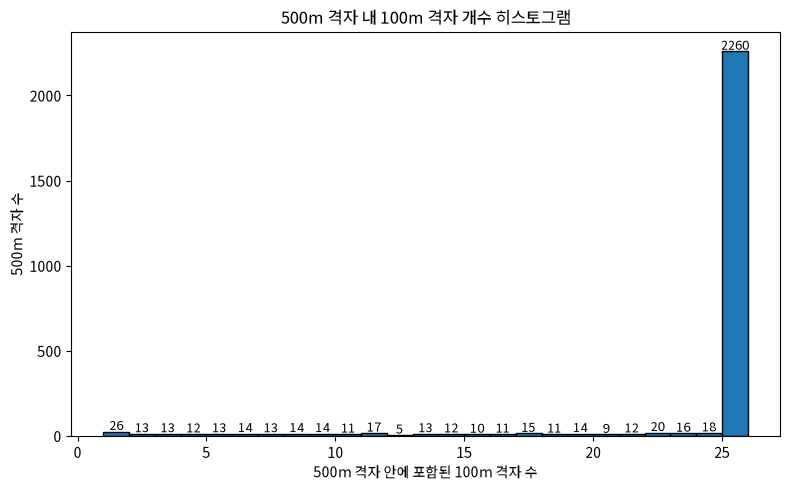

In [11]:
from shapely.geometry import Point
grid100_point = grid100.copy()
grid100_point["geometry"] = gpd.points_from_xy(
    grid100_point["중심점_x"],
    grid100_point["중심점_y"]
)

grid100_point = gpd.GeoDataFrame(
    grid100_point,
    geometry = "geometry",
    crs = grid100_point.crs
)

print(f"그리드100 point 지오타입: {grid100_point.geometry.geom_type.unique()}")
print(f"그리드100 poin crs: {grid100_point.crs}")
print(f"데이터 행 개수 확인: {len(grid100)}, {len(grid100_point)}")
# 그리드100 point 지오타입: ['Point']
# 그리드100 poin crs: EPSG:5179
# 데이터 행 개수 확인: 60528, 60528

# 500m 인구 공간 결합

grid100_500 = gpd.sjoin(
    grid100_point[["GRID_CD", "geometry"]],
    pop500_clean[["GRID_CD_500", "geometry"]],
    how = 'left',
    predicate = 'within'
)

grid100_500 = grid100_500.drop(columns= "index_right")
grid100_500.head()

print(f"공간결합 결측치 확인: {grid100_500.isna().sum()}")
grid_check = grid100_500.groupby(by="GRID_CD_500")["GRID_CD"].size().reset_index(name="100격자수")
print(f"공간결합 격자수 확인: {grid_check["100격자수"].value_counts()}")
display(grid_check.sort_values("100격자수", ascending=True))


# 500 격자 내 100 격자 분포도 시각화
plt.rcParams["font.family"] = "Noto Sans KR"

fig, ax = plt.subplots(figsize=(8, 5))

counts, bins, patches = ax.hist(
    grid_check["100격자수"],
    bins=range(
        int(grid_check["100격자수"].min()),
        int(grid_check["100격자수"].max()) + 2
    ),
    edgecolor="black"
)

ax.set_title("500m 격자 내 100m 격자 개수 히스토그램")
ax.set_xlabel("500m 격자 안에 포함된 100m 격자 수")
ax.set_ylabel("500m 격자 수")

for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        ax.text(
            x,
            y,
            str(int(count)),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    IMAGE_PATH / "500m 격자 내 100m 격자 개수 히스토그램.png",
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()


In [12]:
# 500격자 코드 100격자에 결합
grid_merge = pd.merge(
    grid100_pop,
    grid100_500[["GRID_CD", "GRID_CD_500"]],
    on = "GRID_CD",
    how = 'left'
)

print(f"결측치 확인: {grid_merge.isna().sum()}")
print(f"중복값 확인: {grid_merge.duplicated(["GRID_CD", "GRID_CD_500"]).sum()}")
display(
    grid_merge.head()
)
# 결측치 확인: GRID_CD        0
# 행정동코드          0
# 시군구            0
# 행정동            0
# 중심점_x          0
# 중심점_y          0
# geometry       0
# GRID_CD_500    0
# dtype: int64
# 중복값 확인: 0
# 이상 없음!


결측치 확인: GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
geometry       0
총인구수           0
GRID_CD_500    0
dtype: int64
중복값 확인: 0


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,geometry,총인구수,GRID_CD_500
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,"POLYGON ((960300 1936700, 960300 1936800, 9604...",0.0,다사60a36b
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,"POLYGON ((960400 1936700, 960400 1936800, 9605...",0.0,다사60a36b
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,"POLYGON ((960500 1936700, 960500 1936800, 9606...",0.0,다사60b36b
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,"POLYGON ((961500 1936700, 961500 1936800, 9616...",0.0,다사61b36b
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,"POLYGON ((960200 1936800, 960200 1936900, 9603...",0.0,다사60a36b


2586 2634
제외 500 격자 개수: 48


,GRID_CD_500,총인구수_500,geometry
0,다사35a50a,0.0,"POLYGON ((935000 1950000, 935000 1950500, 9355..."
6,다사35b51b,0.0,"POLYGON ((935500 1951500, 935500 1952000, 9360..."
7,다사35b52a,0.0,"POLYGON ((935500 1952000, 935500 1952500, 9360..."
14,다사36a52b,0.0,"POLYGON ((936000 1952500, 936000 1953000, 9365..."
45,다사37b55a,0.0,"POLYGON ((937500 1955000, 937500 1955500, 9380..."
46,다사37b55b,0.0,"POLYGON ((937500 1955500, 937500 1956000, 9380..."
63,다사38b49a,0.0,"POLYGON ((938500 1949000, 938500 1949500, 9390..."
80,다사39a43b,0.0,"POLYGON ((939000 1943500, 939000 1944000, 9395..."
82,다사39a44b,0.0,"POLYGON ((939000 1944500, 939000 1945000, 9395..."
117,다사39b55b,0.0,"POLYGON ((939500 1955500, 939500 1956000, 9400..."


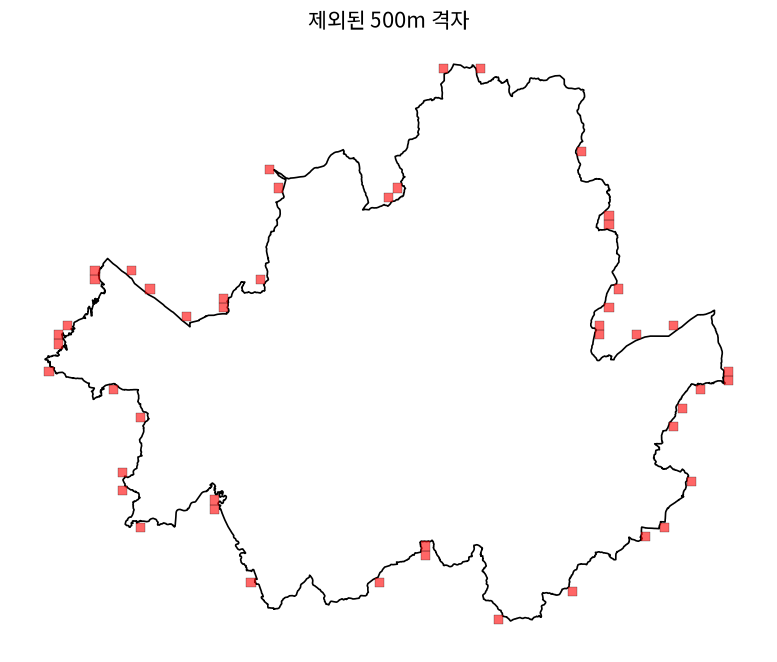

In [13]:
# 500 격자 개수확인
print((grid_merge["GRID_CD_500"].nunique()), len(pop500_clean))
# 2586 2634
# 병합된 테이블에서 500 격자 고유 개수가 더 적음
# left join 하면서 100 격자 중심점이 500 안에 들어가지 않은 격자일 가능성

# 제외된 500 격자 확인
missing_500 = pop500_clean[~(pop500_clean["GRID_CD_500"].isin(grid_merge["GRID_CD_500"]))]
print(f"제외 500 격자 개수: {len(missing_500)}")
display(
    missing_500
)
# 제외 500 격자 개수: 48

# 제외 500 격자 - 서울시 경계 비교 시각화
hjd = gpd.read_file(
    DATA_PATH / "raw" / "spatial" / "boundary" / "BND_ADM_DONG_PG.shp",
    encoding="cp949"
)
hjd_seoul = hjd[hjd["ADM_CD"].str.startswith("11")].copy()
hjd_seoul = hjd_seoul.to_crs(missing_500.crs)
seoul_boundary = hjd_seoul.dissolve()

fig, ax = plt.subplots(figsize = (12, 8))
seoul_boundary.plot(
    ax= ax,
    facecolor = "None",
    edgecolor = 'black',
    linewidth = 1.2
    )
missing_500.plot(
    ax=ax,
    color="red",
    alpha=0.6,
    edgecolor="black",
    linewidth=0.3
)
plt.title("제외된 500m 격자", fontsize=15)
ax.set_axis_off()
plt.savefig(IMAGE_PATH / "제외된 500m 격자.png",
            dpi = 240,
            pad_inches = 0.1,
            bbox_inches = 'tight')
plt.show()


결측치 확인: GRID_CD_500    0
100m인구수합       0
총인구수_500       0
dtype: int64
중복값 확인: 0
행 수 확인: 2586
인구수 오차 합: 5702.0


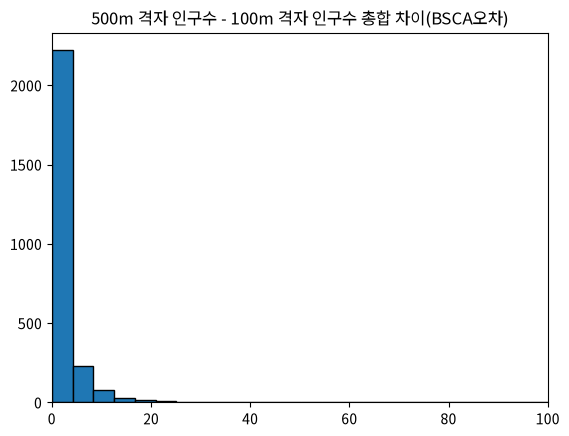

In [14]:
# GRID_CD_500 그룹 기준 인구수 합 -> GRID_CD_500 인구수와 비교

# 100m 인구수 500m 기준으로 sum
pop_total_100 = grid_merge.groupby("GRID_CD_500")["총인구수"].sum().reset_index(name = "100m인구수합")
pop_total_100.head()

pop_total_500 = pop500_clean[pop500_clean["GRID_CD_500"].isin(grid_merge["GRID_CD_500"])]

# 인구수 merge
pop_total_merge = pop_total_100.merge(
    pop_total_500[["GRID_CD_500", "총인구수_500"]],
    on = "GRID_CD_500",
    how = 'left'
)

# 결측치 확인: GRID_CD_500    0
# 100m인구수합       0
# 총인구수_500       0
# dtype: int64
# 중복값 확인: 0
# 행 수 확인: 2586
# 인구수 오차 합: -5702.0
# 100m 격자 인구수가 더많은 경우는 없었으며, 대부분 -1 ~ -5 수준.
# 5702 인구수 적음, 결측치 중복치 없음, 성공!


print(f"결측치 확인: {pop_total_merge.isna().sum()}")
print(f"중복값 확인: {pop_total_merge["GRID_CD_500"].duplicated().sum()}")
print(f"행 수 확인: {len(pop_total_merge)}")

pop_total_merge["인구수차이"] = pop_total_merge["총인구수_500"] - pop_total_merge["100m인구수합"]
print(f"인구수 오차 합: {pop_total_merge["인구수차이"].sum(axis=0)}")

plt.hist(pop_total_merge["인구수차이"], bins=100, edgecolor='black' )
plt.title("500m 격자 인구수 - 100m 격자 인구수 총합 차이(BSCA오차)")
plt.xlim((0, 100))
plt.savefig(IMAGE_PATH / "500m_100m_BSCA오차_히스토그램분포.png", 
            pad_inches=0.1,
            bbox_inches='tight')
plt.show()


## 추정 테이블 만들기

### 주거용도면적 데이터 점검
# 주거용도 면적 결측치 점검
    # 점검방식: 0으로 처리 후 그리드 코드 기준 결합, 기본 테이블과 결합 이후 주거면적 0인 곳과 인구수 비교
    # 주거면적 0 지역 레코드수: 40276
    # 주거면적 0 지역 총 인구 합 3951877.0
    # count    40276.000000
    # mean        98.119898
    # std        240.850700
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max      12522.000000
    # 결론: 주거면적 0 격자 대부분은 인구가 없지만, 일부 격자에는 상당한 인구가 존재하여 주거용도 면적 단독 보정 기준은 리스크가 큼, 
    # 원자료 값은 임의 대체하지 않고 0으로 유지하되, 보정 가중치 산정 시 기존 100m 인구수 등 다른 변수와 함께 사용하는 방식으로 검토함.

주거용도면적 crs: EPSG:5179
주거용도면적 지오타입: <StringArray>
['Polygon']
Length: 1, dtype: str
주거용도면적 레코드 수: 64681
주거용도면적 결측치
GRID_CD         0
주거면적        44283
geometry        0
시군구             0
dtype: int64
주거용도면적 GRID CODE 중복치
3029


,GRID_CD,주거면적,geometry,시군구
0,다사565474,NaN,"POLYGON ((956500 1947400, 956500 1947500, 9566...",강남구
1,다사565475,NaN,"POLYGON ((956500 1947500, 956500 1947600, 9566...",강남구
2,다사566473,NaN,"POLYGON ((956600 1947300, 956600 1947400, 9567...",강남구
3,다사566474,NaN,"POLYGON ((956600 1947400, 956600 1947500, 9567...",강남구
4,다사566475,NaN,"POLYGON ((956600 1947500, 956600 1947600, 9567...",강남구


주거면적 결측처리 확인: 0
주거면적 중복값 확인: 0
주거면적 0 지역 레코드수: 40276
주거면적 0 지역 총 인구 합 3951877.0


count    40276.000000
mean        98.119898
std        240.850700
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      12522.000000
Name: 총인구수, dtype: float64

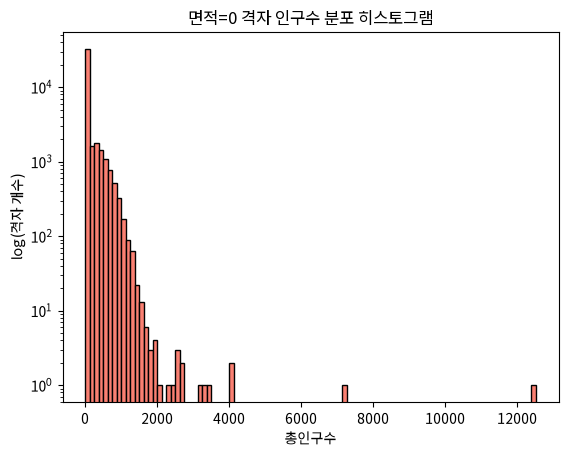

In [15]:
# 추정 테이블 만들기

# (1) 기본 테이블에 주요 변수 붙이기
# 주거용도면적
HOUSE_AREA_PATH = GRID_PATH / "주거용도면적"
house_area_list = list(HOUSE_AREA_PATH.glob("*/vl_blk.shp"))

df_list = []
for area in house_area_list:
    result = gpd.read_file(area, encoding='utf-8')
    result["시군구"] = area.parent.name
    df_list.append(result)
    
house_area = gpd.GeoDataFrame(
    pd.concat(df_list, 
              ignore_index=True),
    geometry = "geometry",
    crs = df_list[0].crs
)

house_area = house_area[["gid", "val", "geometry", "시군구"]]

house_area = house_area.rename(
    columns= {"gid": "GRID_CD",
     "val": "주거면적"}
    )

print(f"주거용도면적 crs: {house_area.crs}")
print("="*100)
print(f"주거용도면적 지오타입: {house_area.geometry.geom_type.unique()}")
print("="*100)
print(f"주거용도면적 레코드 수: {len(house_area)}")
print("="*100)
print("주거용도면적 결측치")
print(house_area.isna().sum())
print("="*100)
print("주거용도면적 GRID CODE 중복치")
print(house_area.duplicated(["GRID_CD", "geometry"]).sum())

display(house_area.head())

    
house_area_check = house_area.copy()
house_area_check["주거면적"] = house_area_check["주거면적"].fillna(0)
print(f"주거면적 결측처리 확인: {house_area_check["주거면적"].isna().sum()}")

house_area_check = house_area_check.groupby(by = "GRID_CD", 
                                             as_index = False) \
                                                 ["주거면적"].sum()

print(f"주거면적 중복값 확인: {house_area_check["GRID_CD"].duplicated().sum()}")
# 주거면적 결측처리 확인: 0
# 주거면적 중복값 확인: 0
grid_merge_check = grid_merge.copy()

pop_area_check = grid_merge.merge(house_area_check[["GRID_CD", "주거면적"]],
                                  on = "GRID_CD",
                                  how = "left")
pop_zero_area = pop_area_check[pop_area_check["주거면적"] == 0]
print(f"주거면적 0 지역 레코드수: {len(pop_zero_area)}")
print(f"주거면적 0 지역 총 인구 합 {pop_zero_area["총인구수"].sum()}")
display(pop_zero_area["총인구수"].describe())
plt.hist(pop_zero_area["총인구수"], 
         color = 'salmon',
         edgecolor = 'black',
         bins = 100)
plt.title("면적=0 격자 인구수 분포 히스토그램")
plt.yscale('log')
plt.ylabel("log(격자 개수)")
plt.xlabel("총인구수")
plt.savefig(IMAGE_PATH / '면적0_격자_인구수분포_히스토그램.png',
            bbox_inches = 'tight',
            pad_inches = 0.1,
            dpi = 240)
plt.show()


### 주거면적 데이터 전처리
    # 결측치를 임시로 0으로 설정, 
    # GRID_CD 기준 결합하여 중복값 제거

In [16]:
# 주거면적 결측치, 중복치 제거 (그룹 기준합)
    # 결측치를 임시로 0으로 설정, 
    # GRID_CD 기준 결합하여 중복값 제거
house_area["주거면적"] = house_area["주거면적"].fillna(0)

house_area_clean = house_area.groupby(by="GRID_CD", as_index=False)["주거면적"].sum()
print(f"주거면적 결측 처리 확인 \n: {house_area_clean.isna().sum()}")
print(f"주거면적 중복 처리 확인: {house_area_clean["GRID_CD"].duplicated().sum()}")
print("="*100)
# 주거면적 결측 처리 확인 
# GRID_CD    0
# 주거면적       0
# 주거면적 중복 처리 확인: 0
# 성공!


주거면적 결측 처리 확인 
: GRID_CD    0
주거면적       0
dtype: int64
주거면적 중복 처리 확인: 0


### 기본 테이블 - 주거면적 테이블 결합

In [17]:
    #(1) 주거면적 변수와 결합
grid_area_merge = grid_merge.merge(
    house_area_clean[["GRID_CD", "주거면적"]],
    on = "GRID_CD",
    how = 'left'
)

print("주거면적 병합후 결측치")
print(grid_area_merge.isna().sum())
print(f"주거면적 병합 후 그리드코드 중복: {grid_area_merge["GRID_CD"].duplicated().sum()}")
print("="*100)


주거면적 병합후 결측치
GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
geometry       0
총인구수           0
GRID_CD_500    0
주거면적           0
dtype: int64
주거면적 병합 후 그리드코드 중복: 0


### 주택수 데이터 점검
    # 주택수 레코드 수: 168189
    # ====================================================================================================
    # 주택수 결측치
    # 연도         0
    # GRID_CD    0
    # 통계코드       0
    # 주택수        0
    # dtype: int64
    # ====================================================================================================
    # 주택수 GRID CODE 중복치
    # 0
    # 결측치, 중복값은 없으나 레코드 수가 서울 격자 개수 대비 과대 -> 대다수 격자 서울 외 지역 가능성
    # count    30916.000000
    # mean         4.644812
    # std         66.131885
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max       7191.000000
    # Name: 총인구수, dtype: float64
    # 점검 결과, 주거면적이 제공되지 않는 격자를 일괄 0으로 처리할 경우
    # 인구가 존재하는 일부 격자가 보정 가중치에서 제외될 가능성이 큼
    # 히스토그램과 지도 확인 결과, 주거면적 0 격자 중에서도 무시하기 어려운 인구 분포가 확인됨
    # 따라서 주거면적은 단독 보정 변수로 사용하지 않고,
    # 기존 100m 인구수 등 다른 변수와 결합한 혼합 보정 방식에서 사용


In [18]:
# (2) 주택수
HOUSE_COUNT_PATH = GRID_PATH / "주택수"
house_count = pd.read_csv(HOUSE_COUNT_PATH / "2024년_주택_다사_100M.csv", 
                          header = None,
                          names = ["연도", "GRID_CD", "통계코드", "주택수"],
                          encoding='cp949')


print(f"주택수 레코드 수: {len(house_count)}")
print("="*100)
print("주택수 결측치")
print(house_count.isna().sum())
print("="*100)
print("주택수 GRID CODE 중복치")
print(house_count.duplicated(["GRID_CD"]).sum())


주택수 레코드 수: 168189
주택수 결측치
연도         0
GRID_CD    0
통계코드       0
주택수        0
dtype: int64
주택수 GRID CODE 중복치
0


격자 테이블 - 주택수 테이블 그리드 코드 비교: (60528, np.int64(29612))


,GRID_CD,행정동,총인구수,주거면적
0,다사603367,양재2동,0.0,0.0
1,다사604367,양재2동,0.0,0.0
2,다사605367,양재2동,0.0,0.0
3,다사615367,내곡동,0.0,0.0
4,다사602368,양재2동,0.0,0.0
5,다사603368,양재2동,0.0,0.0
6,다사604368,양재2동,0.0,0.0
7,다사605368,양재2동,0.0,0.0
8,다사606368,양재2동,0.0,0.0
9,다사607368,양재2동,0.0,0.0


count    30916.000000
mean         4.644812
std         66.131885
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       7191.000000
Name: 총인구수, dtype: float64

count    30916.000000
mean         0.897079
std         16.473829
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        996.450000
Name: 주거면적, dtype: float64

missing 주택수의 인구수>0 레코드 수: 820


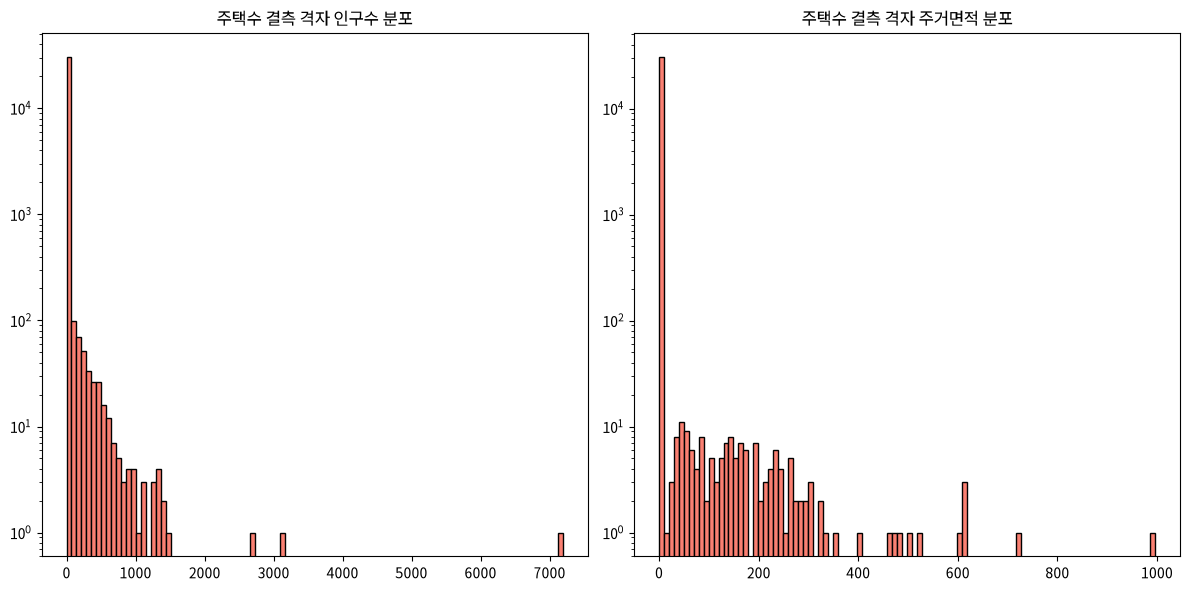

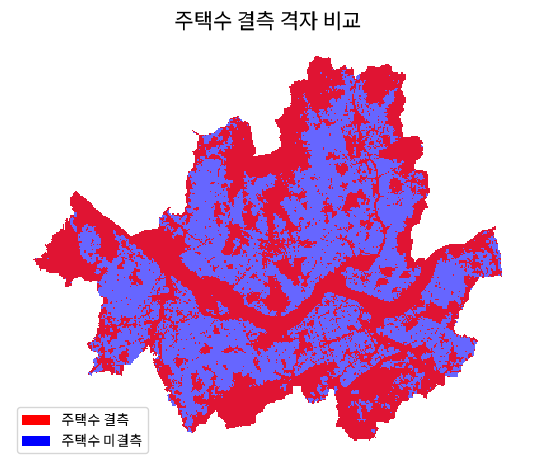

In [19]:
# 주택수 GRID_CD missing in grid 100m 확인
# 그리드 코드 개수 확인
print(f"격자 테이블 - 주택수 테이블 그리드 코드 비교: {len(grid_merge["GRID_CD"]), house_count["GRID_CD"].isin(grid_merge["GRID_CD"]).sum()}")
# 60528 29612
# 약 절반 이상의 격자가 주택수 데이터에 없음

# 주택수 데이터에 결측값, 중복값 없음 -> 주택수 제공되지 않거나 0인 격자 데이터는 제공되지 않을 가능성
missing_house_count_idx = ~(grid_area_merge["GRID_CD"].isin(house_count["GRID_CD"]))
missing_house_count = grid_area_merge[missing_house_count_idx]

display(missing_house_count[["GRID_CD", "행정동", "총인구수", "주거면적"]].head(20))
display(missing_house_count["총인구수"].describe())
display(missing_house_count["주거면적"].describe())


print(f"missing 주택수의 인구수>0 레코드 수: {(missing_house_count["총인구수"]>0).sum()}")
# missing 주택수의 인구수>0 레코드 수: 820
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(missing_house_count["총인구수"],
        color = 'salmon',
        edgecolor = 'black',
        bins = 100)
axs[0].set_yscale('log')
axs[0].set_title("주택수 결측 격자 인구수 분포")

axs[1].hist(missing_house_count["주거면적"],
         edgecolor='black',
         color = 'salmon',
         bins = 100)
axs[1].set_title("주택수 결측 격자 주거면적 분포")
axs[1].set_yscale('log')
plt.tight_layout()
plt.savefig(IMAGE_PATH / "주택수결측격자_총인구수_주거면적_히스토그램.png",
            bbox_inches = 'tight',
            pad_inches = 0.1, 
            dpi = 240)
plt.show()


from matplotlib.patches import Patch

fig, ax = plt.subplots()
grid_area_merge.plot(
    ax=ax,
    color="blue",
    edgecolor="none",
    alpha=0.6
)

missing_house_count.plot(
    ax=ax,
    color="red",
    edgecolor="none",
    alpha=0.8
)

legend_elements = [
    Patch(facecolor="red", edgecolor="none", label="주택수 결측"),
    Patch(facecolor="blue", edgecolor="none", label="주택수 미결측")
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True
)

ax.set_title("주택수 결측 격자 비교", fontsize = 15)
ax.set_axis_off()
plt.savefig(IMAGE_PATH / "주택수_결측_미결측_격자비교_지도.png",
            bbox_inches = 'tight',
            pad_inches = 0.1, 
            dpi = 240)
plt.tight_layout()
plt.show()




#### 기본 테이블 - 주택수 테이블 결합
    # 결합 테이블 레코드 수: 60528
    # 결합 테이블 격자 코드 중복값 : 0
    # 결합 테이블 결측치: 
    # GRID_CD            0
    # 행정동코드              0
    # 시군구                0
    # 행정동                0
    # 중심점_x              0
    # 중심점_y              0
    # geometry           0
    # 총인구수               0
    # GRID_CD_500        0
    # 주거면적               0
    # 주택수            30916
    # dtype: int64
    # 주택수 결측 처리 확인: 0

In [20]:
grid_area_count = grid_area_merge.merge(house_count[["GRID_CD", "주택수"]],
                                        on = "GRID_CD",
                                        how = "left")

print(f"결합 테이블 레코드 수: {len(grid_area_count)}")
print(f"결합 테이블 격자 코드 중복값 : {grid_area_count["GRID_CD"].duplicated().sum()}")
print(f"결합 테이블 결측치: \n{grid_area_count.isna().sum()}")


# 주택수 결측 0으로 일괄 처리
grid_area_count["주택수"] = grid_area_count["주택수"].fillna(0)
print(f"주택수 결측 처리 확인: {grid_area_count["주택수"].isna().sum()}")
# 주택수 결측 처리 확인: 0
# 성공!
        


결합 테이블 레코드 수: 60528
결합 테이블 격자 코드 중복값 : 0
결합 테이블 결측치: 
GRID_CD            0
행정동코드              0
시군구                0
행정동                0
중심점_x              0
중심점_y              0
geometry           0
총인구수               0
GRID_CD_500        0
주거면적               0
주택수            30916
dtype: int64
주택수 결측 처리 확인: 0


### 100m 격자 인구수 - 보정 후보 변수 관계 확인


#### 상관계수확인

    # 주택수는 총인구수와 매우 강한 양의 상관관계를 보임.
    # 특히 Spearman 상관계수가 0.96으로 높아, 격자별 인구 규모의 순위를 상당히 잘 설명함.
    # 반면:
    # 주거면적은 총인구수와 양의 관계는 있으나,
    # 주택수에 비해 상관이 약함.
    # 산점도에서도 주거면적이 0 또는 낮은데 인구가 높은 격자가 일부 확인됨.
    # 따라서 결론은:
    # BSCA 오차 배분 기준으로는 주거면적보다 주택수가 더 적합함.

<class 'pandas.DataFrame'>
RangeIndex: 60528 entries, 0 to 60527
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   총인구수    60528 non-null  float64
 1   주택수     60528 non-null  float64
 2   주거면적    60528 non-null  float64
dtypes: float64(3)
memory usage: 1.4 MB


,총인구수,주택수,주거면적
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


None

총인구수    0
주택수     0
주거면적    0
dtype: int64

,총인구수,주택수,주거면적
총인구수,1.000000,0.888411,0.305992
주택수,0.888411,1.000000,0.262829
주거면적,0.305992,0.262829,1.000000


,총인구수,주택수,주거면적
총인구수,1.000000,0.960681,0.589361
주택수,0.960681,1.000000,0.575137
주거면적,0.589361,0.575137,1.000000


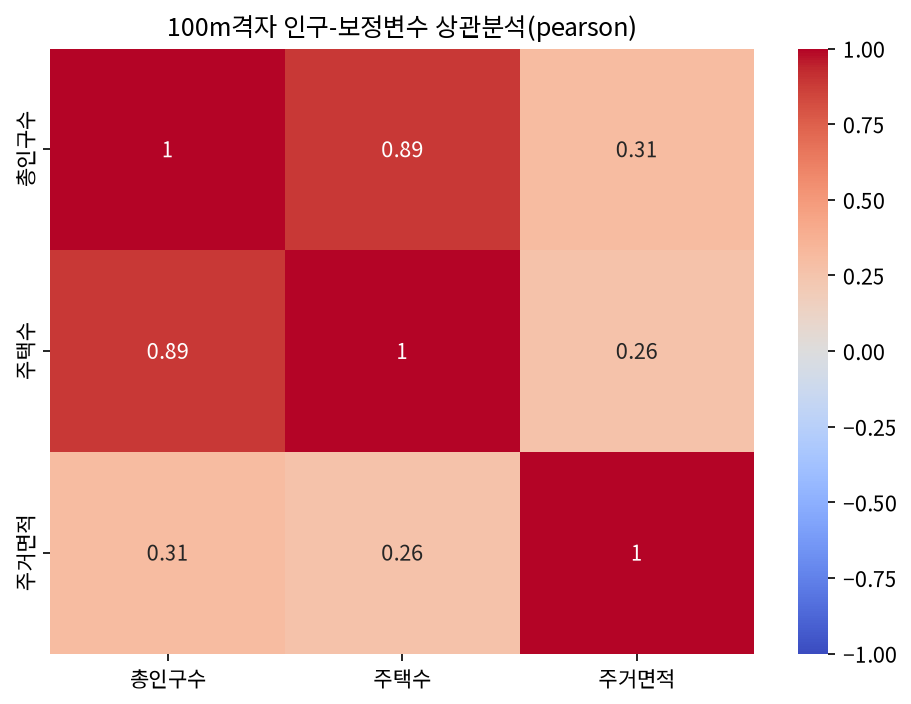

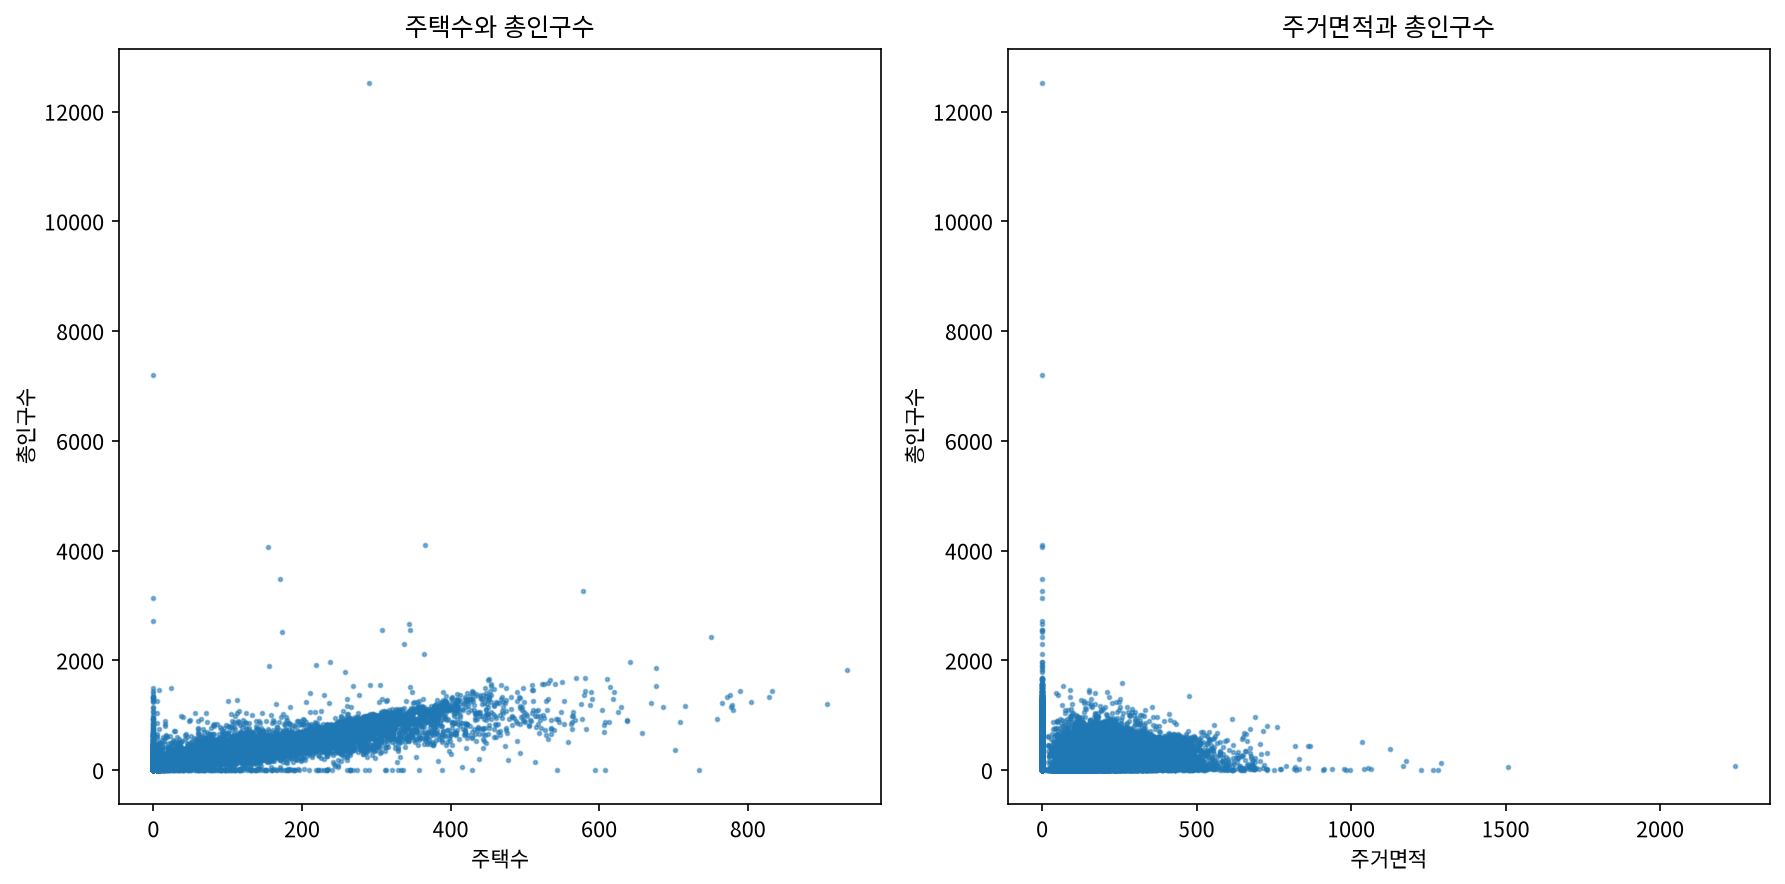

In [21]:
# 변수별 상관분석
# Pearson: 값 크기의 선형 관계
# Spearman: 순위 관계

    # 주택수는 총인구수와 매우 강한 양의 상관관계를 보임.
    # 특히 Spearman 상관계수가 0.96으로 높아, 격자별 인구 규모의 순위를 상당히 잘 설명함.
    # 반면:
    # 주거면적은 총인구수와 양의 관계는 있으나,
    # 주택수에 비해 상관이 약함.
    # 산점도에서도 주거면적이 0 또는 낮은데 인구가 높은 격자가 일부 확인됨.
    # 따라서 결론은:
    # BSCA 오차 배분 기준으로는 주거면적보다 주택수가 더 적합함.
    
corr_cols = grid_area_count[["총인구수", "주택수", "주거면적"]].copy()

display(corr_cols.head(),
corr_cols.info(),
corr_cols.isna().sum()
)

# 피어슨 스피어만 상관계수
corr_pearson = corr_cols.corr(method = 'pearson')
corr_spearman = corr_cols.corr(method = 'spearman')

display(corr_pearson,
corr_spearman
)

# 히트맵, 산점도 시각 자료
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(dpi=150)

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("100m격자 인구-보정변수 상관분석(pearson)")
plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1, 2, dpi=150, figsize=(12, 6))

axs[0].scatter(
    grid_area_count["주택수"],
    grid_area_count["총인구수"],
    s=3,
    alpha=0.5
)
axs[0].set_title("주택수와 총인구수")
axs[0].set_xlabel("주택수")
axs[0].set_ylabel("총인구수")

axs[1].scatter(
    grid_area_count["주거면적"],
    grid_area_count["총인구수"],
    s=3,
    alpha=0.5
)
axs[1].set_title("주거면적과 총인구수")
axs[1].set_xlabel("주거면적")
axs[1].set_ylabel("총인구수")

plt.tight_layout()
plt.show()


### 100m 격자별 인구 보정 실험
    # 1. 500m 격자별 주택수 비중 100%
    # 2. 500m 격자별 주택수 비중 70% + 총인구수 30%
    # 3. 500m 격자별 주택수 비중 50% + 총인구수 30%
    # 1-3안 생성 후 행정동 별 인구수 오차 비교

#### 지수 생성


In [22]:
# 비중으로 변환
grid_pop_test = grid_area_count[["GRID_CD", "GRID_CD_500", "총인구수", "주택수", "주거면적"]].copy()

grid_pop_test["500총인구수"] = grid_pop_test.groupby(by = "GRID_CD_500")["총인구수"].transform('sum')
grid_pop_test["500주택수"] = grid_pop_test.groupby(by = "GRID_CD_500")["주택수"].transform('sum')
grid_pop_test["500주거면적"] = grid_pop_test.groupby(by = "GRID_CD_500")["주거면적"].transform('sum')

grid_pop_test["인구수비중"] = np.where(grid_pop_test["500총인구수"]>0, grid_pop_test["총인구수"] / grid_pop_test["500총인구수"], 0)
grid_pop_test["주택수비중"] = np.where(grid_pop_test["500주택수"]>0, grid_pop_test["주택수"] / grid_pop_test["500주택수"], 0)
grid_pop_test["주거면적비중"] = np.where(grid_pop_test["500주거면적"]>0, grid_pop_test["주거면적"] / grid_pop_test["500주거면적"], 0)

ratio = grid_pop_test.groupby(by = "GRID_CD_500")[["인구수비중", "주택수비중", "주거면적비중"]].sum()
display(ratio.describe())

# 비중이 0인 칼럼이 인구수 약 26%, 주택수 약 26%, 주거면적 약 27% 존재



,인구수비중,주택수비중,주거면적비중
count,2586.000000,2586.000000,2586.000000
mean,0.740913,0.734339,0.629930
std,0.438218,0.441770,0.482916
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


In [23]:
grid_pop_test.head()

# 지수1: 주택수 100%
grid_pop_test["지수1"] = (0 * grid_pop_test["인구수비중"]) + (1 * grid_pop_test["주택수비중"])

# 지수2: 인구수 30% + 주택수 70%
grid_pop_test["지수2"] = (0.3 * grid_pop_test["인구수비중"]) + (0.7 * grid_pop_test["주택수비중"])

# 지수3: 인구수 50% + 주택수 50%
grid_pop_test["지수3"] = (0.5 * grid_pop_test["인구수비중"]) + (0.5 * grid_pop_test["주택수비중"])

# 지수4: 인구수 30% + 주택수 50% + 주거면적 20%
grid_pop_test["지수4"] = (0.3 * grid_pop_test["인구수비중"]) + (0.5 * grid_pop_test["주택수비중"]) + (0.2 * grid_pop_test["주거면적비중"])

# 지수 확인
grid_pop_check = grid_pop_test.groupby(by = "GRID_CD_500")[["지수1", "지수2", "지수3", "지수4"]].sum()
display(grid_pop_check.describe())

print((grid_pop_check["지수1"]==0).sum())
print((grid_pop_check["지수2"]==0).sum())
print((grid_pop_check["지수3"]==0).sum())
print((grid_pop_check["지수4"]==0).sum())

grid_pop_check.head()


,지수1,지수2,지수3,지수4
count,2586.000000,2586.000000,2586.000000,2586.000000
mean,0.734339,0.736311,0.737626,0.715429
std,0.441770,0.433750,0.431689,0.422489
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.300000,0.500000,0.300000
50%,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


687
641
641
622


,지수1,지수2,지수3,지수4
GRID_CD_500,,,,
다사35a50b,0.0,0.0,0.0,0.0
다사35a51a,0.0,0.0,0.0,0.2
다사35b50a,0.0,0.0,0.0,0.0
다사35b50b,0.0,0.0,0.0,0.0
다사35b51a,0.0,0.0,0.0,0.0


#### 인구잔차 생성

    # 인구잔차 (500m 총인구수 - 500m 내부 100m 총인구수 합)
    # 인구잔차 총합: 5702.0
    # 인구잔차 0 레코드수: 1714
    # 총 5702명의 잔차 인구 분배 필요


    #  인구잔차 0이 아니면서 지수 0인 레코드
    #  인구잔차!=0 & 지수1 = 0 레코드수: 36
    #  인구잔차!=0 & 지수2 = 0 레코드수: 10
    #  인구잔차!=0 & 지수3 = 0 레코드수: 10
    #  인구잔차!=0 & 지수4 = 0 레코드수: 7

    # 소수 인구잔차 !=0 & 지수 = 0 레코드에 대해 균등지수 생성
    #  인구잔차!=0 & 지수1 = 0 레코드수: 36
    #  인구잔차!=0 & 지수2 = 0 레코드수: 10
    #  인구잔차!=0 & 지수3 = 0 레코드수: 10
    #  인구잔차!=0 & 지수4 = 0 레코드수: 7

GRID_CD_500    0
500총인구수        0
총인구수           0
지수1            0
지수2            0
지수3            0
지수4            0
GRID_CD        0
총인구수_500       0
dtype: int64
57942
60528
60528

인구잔차 총합: 5702.0

인구잔차 0 레코드수: 1714


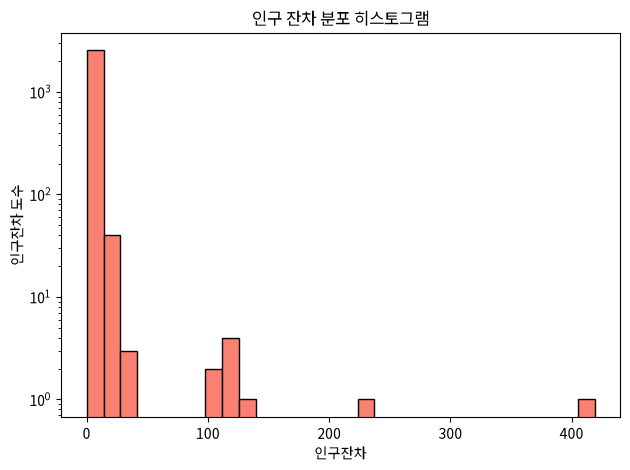


 인구잔차!=0 & 지수1 = 0 레코드수: 36

 인구잔차!=0 & 지수2 = 0 레코드수: 10

 인구잔차!=0 & 지수3 = 0 레코드수: 10

 인구잔차!=0 & 지수4 = 0 레코드수: 7


In [24]:
# 인구잔차 생성
pop_residual = grid_pop_test[["GRID_CD_500", "500총인구수", "총인구수", "지수1", "지수2", "지수3", "지수4", "GRID_CD"]].merge(pop500_clean[["GRID_CD_500", "총인구수_500"]], 
                                                                                                              on = "GRID_CD_500",
                                                                                                              how = "left")

print(pop_residual.isna().sum())
print(pop_residual["GRID_CD_500"].duplicated().sum())
print(len(pop_residual))
print(len(grid_area_count))



pop_residual["인구잔차"] = pop_residual["총인구수_500"] - pop_residual["500총인구수"]


# 인구잔차 검토
residual_500 = pop_residual.groupby(by="GRID_CD_500").agg({"인구잔차": 'first',
                                                           "지수1": 'sum',
                                                           "지수2": 'sum',
                                                           "지수3": 'sum',
                                                           "지수4": 'sum'})

print(f"\n인구잔차 총합: {residual_500["인구잔차"].sum()}")
print(f"\n인구잔차 0 레코드수: {(residual_500["인구잔차"]==0).sum()}")

    #분포확인
plt.hist(residual_500["인구잔차"],
         color = 'salmon',
         edgecolor = 'black',
         bins = 30)
plt.title("인구 잔차 분포 히스토그램")
plt.xlabel("인구잔차")
plt.ylabel("인구잔차 도수")
plt.yscale('log')
plt.tight_layout()
plt.savefig(IMAGE_PATH / "인구잔차_히스토그램.png",
            dpi = 240,
            pad_inches = 0.1,
            bbox_inches = 'tight')
plt.show()



residual_not_zero = residual_500[residual_500["인구잔차"] != 0]
zero_index_1 = residual_not_zero[residual_not_zero["지수1"]==0]
zero_index_2 = residual_not_zero[residual_not_zero["지수2"]==0]
zero_index_3 = residual_not_zero[residual_not_zero["지수3"]==0]
zero_index_4 = residual_not_zero[residual_not_zero["지수4"]==0]

print(f"\n 인구잔차!=0 & 지수1 = 0 레코드수: {len(zero_index_1)}")
print(f"\n 인구잔차!=0 & 지수2 = 0 레코드수: {len(zero_index_2)}")
print(f"\n 인구잔차!=0 & 지수3 = 0 레코드수: {len(zero_index_3)}")
print(f"\n 인구잔차!=0 & 지수4 = 0 레코드수: {len(zero_index_4)}")

    # 소수 인구잔차 !=0 & 지수 = 0 레코드에 대해 균등지수 생성

pop_residual["균등지수"] = (1 / pop_residual.groupby(by = "GRID_CD_500")["GRID_CD"].transform('count'))

pop_residual["지수1합"] = pop_residual.groupby("GRID_CD_500")["지수1"].transform("sum")
pop_residual["지수2합"] = pop_residual.groupby("GRID_CD_500")["지수2"].transform("sum")
pop_residual["지수3합"] = pop_residual.groupby("GRID_CD_500")["지수3"].transform("sum")
pop_residual["지수4합"] = pop_residual.groupby("GRID_CD_500")["지수4"].transform("sum")

pop_residual["지수1_최종"] = np.where(pop_residual["지수1합"] > 0, pop_residual["지수1"], pop_residual["균등지수"])
pop_residual["지수2_최종"] = np.where(pop_residual["지수2합"] > 0, pop_residual["지수2"], pop_residual["균등지수"])
pop_residual["지수3_최종"] = np.where(pop_residual["지수3합"] > 0, pop_residual["지수3"], pop_residual["균등지수"])
pop_residual["지수4_최종"] = np.where(pop_residual["지수4합"] > 0, pop_residual["지수4"], pop_residual["균등지수"])

pop_residual = pop_residual.drop(columns = ["지수1", "지수2", "지수3", "지수4", "지수1합", "지수2합", "지수3합", "지수4합"])
pop_residual = pop_residual.rename(columns = {
    "지수1_최종": "지수1",
    "지수2_최종": "지수2",
    "지수3_최종": "지수3",
    "지수4_최종": "지수4"
})


#### 지수 합 점검
    # 지수 합 점검 (500m 단위 내 지수 합 = 1 이어야, 잔차가 완전히 분배)
    # 지수1합계 점검: 0
    # 지수2합계 점검: 75
    # 지수3합계 점검: 75
    # 지수4합계 점검: 376
    # 지수 1 제외한 지수에 대해 정규화 필요

    # 지수 정규화
    # 지수 합이 1이 아닌 지수에 대해, 각 지수를 500m 단위의 지수합으로 나누어 정규화
    # 정규화지수1합계 점검: 0
    # 정규화지수2합계 점검: 0
    # 정규화지수3합계 점검: 0
    # 정규화지수4합계 점검: 0

In [25]:
# 지수 합 점검 (500m 단위 내 지수 합 = 1 이어야, 잔차가 완전히 분배)
pop_residual_check = pop_residual.groupby(by = "GRID_CD_500")[["지수1", "지수2", "지수3", "지수4"]].sum()
pop_residual_check.head()

idx_cols = ["지수1", "지수2", "지수3", "지수4"]
for idx in idx_cols:
    print(f"{idx}합계 점검: {(~np.isclose(pop_residual_check[idx], 1)).sum()}")

    
# 지수 정규화
for idx in idx_cols:
    idx_sum = pop_residual.groupby(by = "GRID_CD_500")[idx].transform('sum')
    
    pop_residual[f"정규화{idx}"] = np.where(idx_sum > 0, 
                                         pop_residual[idx] / idx_sum, 
                                         pop_residual["균등지수"])

# 지수 정규화 후 지수 합계 점검
pop_residual_check = pop_residual.groupby(by = "GRID_CD_500")[["정규화지수1", "정규화지수2", "정규화지수3", "정규화지수4"]].sum()

idx_cols = ["정규화지수1", "정규화지수2", "정규화지수3", "정규화지수4"]

for idx in idx_cols:
    print(f"{idx}합계 점검: {(~np.isclose(pop_residual_check[idx], 1)).sum()}")
    
# 칼럼버리기
pop_residual = pop_residual.drop(columns = ["지수1", "지수2", "지수3", "지수4", "균등지수"], errors = 'ignore')


지수1합계 점검: 0
지수2합계 점검: 75
지수3합계 점검: 75
지수4합계 점검: 376
정규화지수1합계 점검: 0
정규화지수2합계 점검: 0
정규화지수3합계 점검: 0
정규화지수4합계 점검: 0


#### 인구 잔차 배분
    # 음수 없음 → 보정 과정에서 비현실적인 음수 인구는 발생하지 않음.
    # 보정량 평균 0.094명 → 전체적으로 아주 작은 보정.
    # 75%가 0명 → 대부분 격자는 보정 없음.
    # 최대 보정량은 지수1~3 약 120명, 지수4 약 96명 → 일부 격자에만 잔차가 집중됨.



    # 추정인구수 점검
    # 총량 보존 여부 확인
    # 추정인구수1 총량 보존 확인: 0.0
    # 추정인구수2 총량 보존 확인: 0.0
    # 추정인구수3 총량 보존 확인: 0.0
    # 추정인구수4 총량 보존 확인: 0.0
    # 총량보존 문제없음

    # 이상값 및 보정량 분포 확인
    # count    60528.000000
    # mean         0.094204
    # std          0.998643
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max        122.181818
    # Name: 보정량1, dtype: float64count    60528.000000
    # mean         0.094204
    # std          0.996645
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max        120.622188
    # Name: 보정량2, dtype: float64count    60528.000000
    # mean         0.094204
    # std          0.994785
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max        119.582435
    # Name: 보정량3, dtype: float64count    60528.000000
    # mean         0.094204
    # std          0.948615
    # min          0.000000
    # 25%          0.000000
    # 50%          0.000000
    # 75%          0.000000
    # max         96.185824
    # Name: 보정량4, dtype: float64
    # 지수 1-4 평균 보정량 0.09로 대부분의 격자에서 보정은 일어나지 않음.
    # 최대 보정량은 90-120으로 격자 간 보정 격차 편차가 큼.
    # 지수 4의 max 96, std 0.94로 보정 수준 상대적으로 안정적


추정인구수1 총량 보존 확인: 0.0
추정인구수2 총량 보존 확인: 0.0
추정인구수3 총량 보존 확인: 0.0
추정인구수4 총량 보존 확인: 0.0


count    60528.000000
mean         0.094204
std          0.998643
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        122.181818
Name: 보정량1, dtype: float64

count    60528.000000
mean         0.094204
std          0.996645
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        120.622188
Name: 보정량2, dtype: float64

count    60528.000000
mean         0.094204
std          0.994785
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        119.582435
Name: 보정량3, dtype: float64

count    60528.000000
mean         0.094204
std          0.948615
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         96.185824
Name: 보정량4, dtype: float64

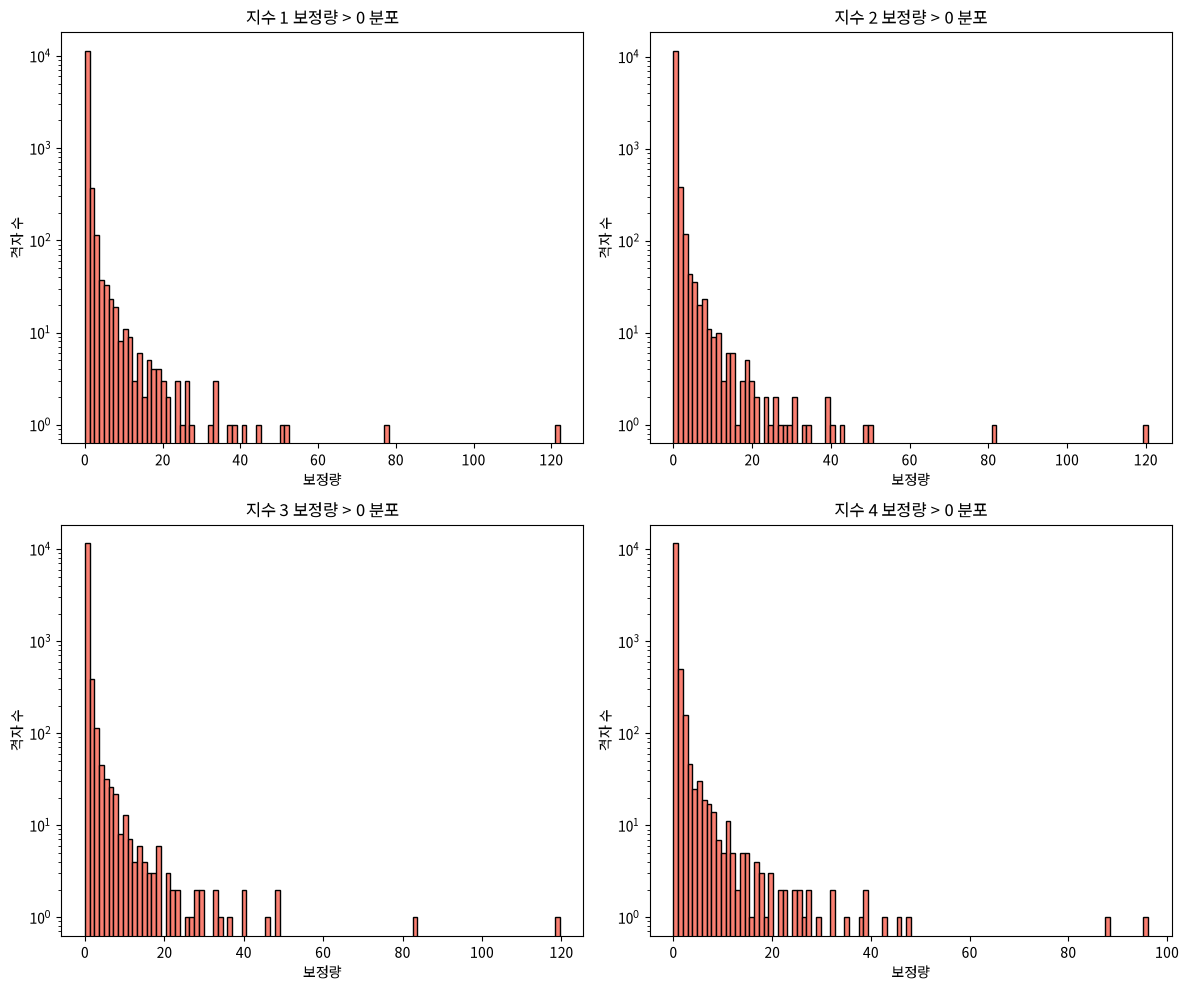

In [26]:
# 배분방식: 레코드별 100m총인구수 + 500m 잔차 x 정규화 지수
est_cols = ["정규화지수1", "정규화지수2", "정규화지수3", "정규화지수4"]

for i, est in enumerate(est_cols):
    pop_residual[f"추정인구수{i+1}"] = (pop_residual["총인구수"] 
                                    + pop_residual["인구잔차"] * pop_residual[est])

# 최종 보정량 점검
pop_residual_check = pop_residual.copy()

est_pop_list = ["추정인구수1", "추정인구수2", "추정인구수3", "추정인구수4"]
for est in est_pop_list:
    result = pop_residual_check.groupby(by = "GRID_CD_500").agg(총인구수500 = ("총인구수_500", 'first'),
                                                                추정인구합 = (est, 'sum'))
    print(f"{est} 총량 보존 확인: {(np.round(result["총인구수500"] - result["추정인구합"], 5).sum())}") 

# 
for i, est in enumerate(est_pop_list):
    pop_residual_check[f"보정량{i+1}"] = (pop_residual_check[est] - pop_residual_check["총인구수"])
    
    display(
        pop_residual_check[f"보정량{i+1}"].describe()
        )
     

    # 히스토그램으로 점검
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for i, ax in enumerate(axs.ravel()):
    col = f"보정량{i+1}"
    data = pop_residual_check[pop_residual_check[col] > 0][col]
    
    ax.hist(
        data,
        bins=100,
        color="salmon",
        edgecolor="black"
    )
    
    ax.set_title(f"지수 {i+1} 보정량 > 0 분포")
    ax.set_xlabel("보정량")
    ax.set_ylabel("격자 수")
    ax.set_yscale("log")

plt.tight_layout()
plt.savefig(IMAGE_PATH / "지수별_보정량_분포_히스토그램.png", 
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.show()


#### 행정동별 인구 파일 불러오기 및 테이블 정리

    - 테이블 정리 및 생성 과정: 2024년 기준으로 필터링 - 시군구 칼럼 생성 - "동별" 칼럼에서 합계, 자치구 값의 행 제거 - 행정동 구분자를 ·로 변경 후 격자 테이블 행정동과 결합

    - 테이블 정리 후 데이터 점검 결과
    # 행정동 인구 결측치: 
    # 시군구         0
    # 행정동별_인구수    0
    # 행정동         0
    # dtype: int64
    # 행정동 인구 데이터 구조: (426, 3)
    # 행정동 총인구수: 9331828

    - 결과물
    # 행정동별_인구수.csv

In [27]:
# 데이터 불러오기 
hjd_pop = pd.read_csv(DATA_PATH / "행정동별_연령별_성별_인구수.csv", 
                      encoding = 'utf-8',
                      on_bad_lines = 'skip',
                      engine="python")


# eda
print(f"행정동 칼럼: {hjd_pop.columns}")
print(f"행정동 shape: {hjd_pop.shape}")
# 행정동 칼럼: Index(['동별', '연령별', '시점', '계', '한국인', '등록외국인', 'Unnamed: 6'], dtype='str')
# 행정동 shape: (19931, 7)


# 칼럼정리
hjd_pop.drop(columns = ["Unnamed: 6", "계", "등록외국인"], inplace=True, errors = 'ignore')


# 결측치 -를 np.nan으로 변환후 결측치 0으로 대체, int로 변환
hjd_pop["한국인"] = hjd_pop["한국인"].str.strip().replace("-", np.nan)
hjd_pop["한국인"] = hjd_pop["한국인"].fillna(0).astype(int)


# 2024년 자료 인덱싱 (격자 = 2024)
hjd_pop = hjd_pop[(hjd_pop["시점"].str.strip() == '2024 년') & (hjd_pop["연령별"] == '합계')]
hjd_pop["시점"] = hjd_pop["시점"].replace("2024 년", '2024')

print(grid_merge["행정동"].nunique(), hjd_pop["동별"].nunique())
# 425 451


# 시군구 칼럼 만들기
gu_list = list(grid_merge["시군구"].unique())

hjd_pop["시군구"] = np.where(hjd_pop["동별"].isin(gu_list), 
                          hjd_pop["동별"],
                          np.nan)

hjd_pop["시군구"] = hjd_pop["시군구"].ffill()

# 실제 동만 남기기
hjd_pop_real = hjd_pop[~(hjd_pop["동별"].isin(["합계"] + gu_list))].copy()
print(len(hjd_pop_real)) 


# 칼럼 명 정리
hjd_pop_real = hjd_pop_real.rename(columns = {"동별": '행정동_s',
                                              "한국인": '행정동별_인구수'})

# 필요한 칼럼만 남기기
hjd_pop_real = hjd_pop_real[["시군구", "행정동_s", "행정동별_인구수"]]

# 병합용 행정동명 통일
hjd_pop_real["행정동"] = hjd_pop_real["행정동_s"].str.replace(".", "·", regex=False)

hjd_pop_real.drop(columns = "행정동_s", inplace=True, errors = 'ignore')

hjd_pop_real = hjd_pop_real[hjd_pop_real["행정동"].isin(grid_merge["행정동"].unique())]


# 데이터 품질 점검
print(f"행정동 인구 결측치: \n{hjd_pop_real.isna().sum()}")
print(f"행정동 인구 데이터 구조: {hjd_pop_real.shape}")
print(f"행정동 총인구수: {hjd_pop_real["행정동별_인구수"].sum(axis=0)}")
display(hjd_pop_real.describe(include='all'))
display(hjd_pop_real.head())


# 파일저장
hjd_pop_real.to_csv(OUTPUT_PATH / "서울시_행정동별_인구수_2024.csv", 
                    encoding = 'utf-8-sig',
                    index = False)


행정동 칼럼: Index(['동별', '연령별', '시점', '계', '한국인', '등록외국인', 'Unnamed: 6'], dtype='str')
행정동 shape: (19931, 7)
425 451
426
행정동 인구 결측치: 
시군구         0
행정동별_인구수    0
행정동         0
dtype: int64
행정동 인구 데이터 구조: (426, 3)
행정동 총인구수: 9331828


,시군구,행정동별_인구수,행정동
count,426,426.000000,426
unique,25,NaN,425
top,송파구,NaN,신사동
freq,27,NaN,2
mean,NaN,21905.699531,NaN
std,NaN,9056.143782,NaN
min,NaN,226.000000,NaN
25%,NaN,15938.750000,NaN
50%,NaN,21136.000000,NaN
75%,NaN,27218.000000,NaN


,시군구,행정동별_인구수,행정동
88,종로구,11030,청운효자동
132,종로구,8962,사직동
176,종로구,2219,삼청동
220,종로구,9051,부암동
264,종로구,17251,평창동


#### 행정동 별 실제 인구수 - 지수 별 추정 인구수 결합

In [28]:
# pop_residual(그리드100 별 추정인구수) - grid_merge(기본 테이블)
    # 그리드-추정인구 테이블 결측치 확인: 
    # GRID_CD        0
    # 행정동코드          0
    # 시군구            0
    # 행정동            0
    # 중심점_x          0
    # 중심점_y          0
    # geometry       0
    # 총인구수           0
    # GRID_CD_500    0
    # 추정인구수1         0
    # 추정인구수2         0
    # 추정인구수3         0
    # 추정인구수4         0
    # dtype: int64
    # 그리드-추정인구 테이블 그리드 코드 중복값 확인: 0
    # 그리드-추정인구 테이블 구조: (60528, 13)


merge_residual = pop_residual[["GRID_CD", "추정인구수1", "추정인구수2", "추정인구수3", "추정인구수4"]].copy()
merge_grid = grid_merge.copy()

compare_pop = merge_grid.merge(merge_residual, 
                               on = "GRID_CD", 
                               how = 'left')

print(f"그리드-추정인구 테이블 결측치 확인: \n{compare_pop.isna().sum()}")
print(f"그리드-추정인구 테이블 그리드 코드 중복값 확인: {compare_pop["GRID_CD"].duplicated().sum()}")
print(f"그리드-추정인구 테이블 구조: {compare_pop.shape}")

# 시군구, 행정동 기준으로 추정인구수 합
hjd_pop_compare = compare_pop.groupby(by = ["시군구", "행정동"]).agg({"추정인구수1": 'sum', 
                                                                    "추정인구수2": 'sum',
                                                                    "추정인구수3": 'sum',
                                                                    "추정인구수4": 'sum'})
                                      
                                      

# 실제 행정동별 인구수 - 추정 인구수 테이블 결합
    # (426, 7)
    # 시군구         0
    # 행정동별_인구수    0
    # 행정동         0
    # 추정인구수1      0
    # 추정인구수2      0
    # 추정인구수3      0
    # 추정인구수4      0
    # dtype: int64
    #     시군구  행정동별_인구수  행정동        추정인구수1        추정인구수2        추정인구수3       추정인구수4
    # 15  강남구     15268  신사동  15326.305372  15326.505266  15326.638528  15325.73738
    # 86  관악구     22171  신사동  22276.000000  22276.000000  22276.000000  22276.00000
hjd_est_compare = hjd_pop_real.merge(hjd_pop_compare, 
                                     on = ["시군구", "행정동"],
                                     how = 'right')
print(hjd_est_compare.shape)
print(hjd_est_compare.isna().sum())
print(hjd_est_compare[hjd_est_compare["행정동"].duplicated(keep=False)])
display(hjd_est_compare.head())


그리드-추정인구 테이블 결측치 확인: 
GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
geometry       0
총인구수           0
GRID_CD_500    0
추정인구수1         0
추정인구수2         0
추정인구수3         0
추정인구수4         0
dtype: int64
그리드-추정인구 테이블 그리드 코드 중복값 확인: 0
그리드-추정인구 테이블 구조: (60528, 13)
(426, 7)
시군구         0
행정동별_인구수    0
행정동         0
추정인구수1      0
추정인구수2      0
추정인구수3      0
추정인구수4      0
dtype: int64
    시군구  행정동별_인구수  행정동        추정인구수1        추정인구수2        추정인구수3       추정인구수4
15  강남구     15268  신사동  15326.305372  15326.505266  15326.638528  15325.73738
86  관악구     22171  신사동  22276.000000  22276.000000  22276.000000  22276.00000


,시군구,행정동별_인구수,행정동,추정인구수1,추정인구수2,추정인구수3,추정인구수4
0,강남구,26341,개포1동,25798.000000,25798.000000,25798.000000,25798.000000
1,강남구,42395,개포2동,41455.582876,41454.391086,41454.396560,41454.314511
2,강남구,16700,개포3동,17677.613086,17677.604600,17677.598942,17677.470726
3,강남구,23123,개포4동,23571.602675,23571.493925,23571.421424,23571.412599
4,강남구,20780,논현1동,20734.941342,20734.335804,20733.932113,20734.460510


#### 행정동별 실제 인구수 - 추정 인구수 오차 비교

,추정인구오차1,추정인구오차2,추정인구오차3,추정인구오차4
count,426.000000,426.000000,426.000000,426.000000
mean,-11.354460,-11.354460,-11.354460,-11.354460
std,742.756637,742.722486,742.679918,742.688036
min,-2038.835243,-2038.829221,-2038.825206,-2038.776305
25%,-289.894944,-289.879904,-289.869878,-289.824240
50%,-41.788008,-41.736852,-41.702748,-42.121359
75%,229.948006,229.927799,229.914328,229.140796
max,10564.588245,10563.061921,10562.044372,10561.850076


,지수,MAE,RMSE,MAPE
3,지수4,405.786635,741.902716,0.029124
2,지수3,405.791350,741.894609,0.029126
0,지수1,405.792292,741.971229,0.029126
1,지수2,405.798848,741.937122,0.029128


,행정동,시군구,행정동별_인구수,추정인구오차4,절대추정인구오차4,오차율4
233,반포본동,서초구,226,-507.070259,507.070259,2.243674
26,둔촌1동,강동구,10917,10561.850076,10561.850076,0.967468
403,을지로동,중구,3095,1344.374738,1344.374738,0.434370
387,종로1·2·3·4가동,종로구,6668,-1966.300675,1966.300675,0.294886
397,동화동,중구,9828,-1923.963992,1923.963992,0.195764
404,장충동,중구,4546,-625.924532,625.924532,0.137687
257,왕십리2동,성동구,15950,1980.188533,1980.188533,0.124150
384,숭인1동,종로구,5728,577.824343,577.824343,0.100877
172,이문1동,동대문구,16546,-1623.603736,1623.603736,0.098127
421,상봉2동,중랑구,20842,-1869.882676,1869.882676,0.089717


,행정동,시군구,행정동별_인구수,추정인구오차4,절대추정인구오차4,오차율4
113,개봉3동,구로구,19304,-1.084937,1.084937,0.000056
207,성산2동,마포구,38519,-3.397784,3.397784,0.000088
58,등촌1동,강서구,24997,2.213712,2.213712,0.000089
88,은천동,관악구,31863,3.108949,3.108949,0.000098
76,난향동,관악구,14618,-1.689106,1.689106,0.000116
391,창신3동,종로구,6231,-0.751312,0.751312,0.000121
124,오류2동,구로구,36108,4.591290,4.591290,0.000127
302,잠실3동,송파구,33769,6.955079,6.955079,0.000206
90,조원동,관악구,19605,4.175826,4.175826,0.000213
195,신대방1동,동작구,23081,7.205077,7.205077,0.000312


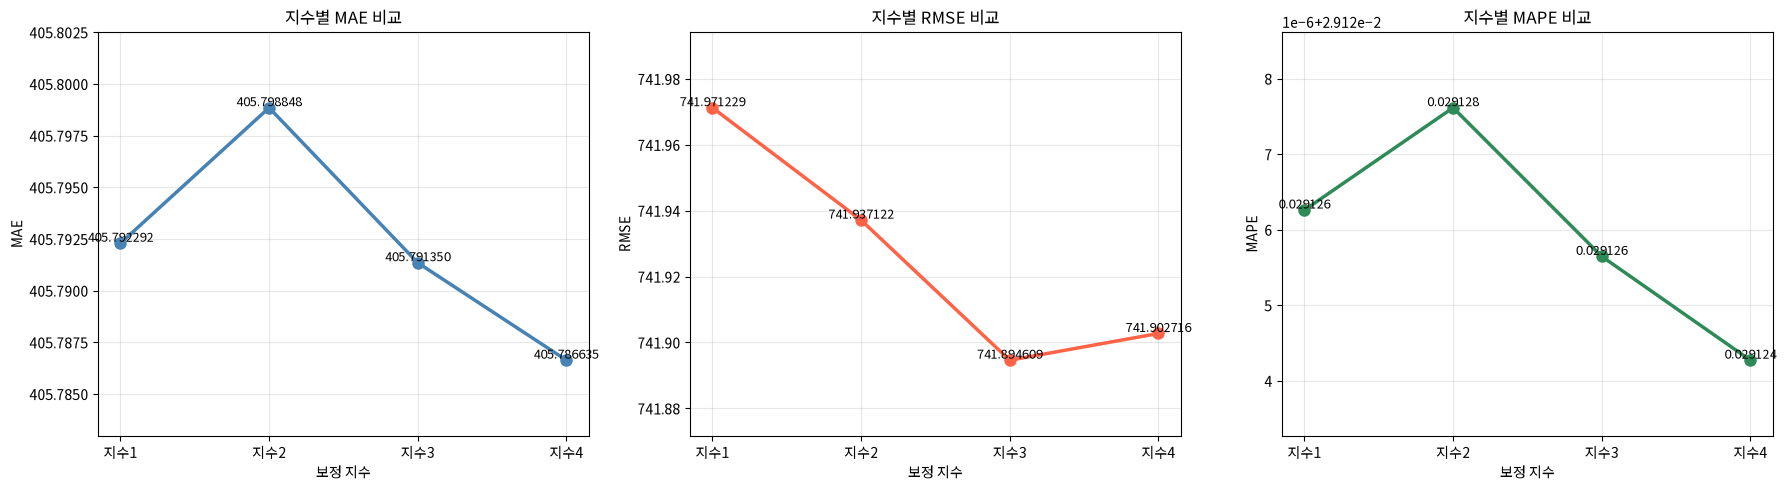

,총인구수,주거면적,주택수
count,89.000000,89.000000,89.000000
mean,3.955056,3.874719,1.101124
std,28.524276,25.928086,8.497386
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,264.000000,230.940000,79.000000


In [29]:
# 지수별 추정오차 계산
# 추정오차 = 행정동별 추정인구수 - 행정동별 실제 인구수

result = hjd_est_compare.copy()

for i in range(1, 5):
    result[f"추정인구오차{i}"] = (
        result["행정동별_인구수"] - result[f"추정인구수{i}"]
    )
    
    result[f"절대추정인구오차{i}"] = result[f"추정인구오차{i}"].abs()
    
    result[f"오차율{i}"] = (
        result[f"절대추정인구오차{i}"] / result["행정동별_인구수"]
    )


index_list = []

for i in range(1, 5):
    mae = result[f"절대추정인구오차{i}"].mean()
    rmse = np.sqrt((result[f"추정인구오차{i}"] ** 2).mean())
    mape = result[f"오차율{i}"].mean()
    
    index_list.append([f"지수{i}", mae, rmse, mape])

index_df = pd.DataFrame(
    index_list,
    columns=["지수", "MAE", "RMSE", "MAPE"]
)

# 오차비교
# 지표를 이용한 비교에서 오차는 모든 지수에 걸쳐 비슷한 수준
# 총인구수, 주택수, 주택면적을 결합한 지수 4에서 MAE와 MAPE가 소폭 높으며 MAE도 지수 3 다음으로 높은 수준
# 따라서 오차 지표에 근거, 지수 4를 최종 추정인구로 채택
# 대부분 지역에서 오차율 10% 미만으로 준수한 추정.
# 하지만 강동구 둔촌1동의 오차율 0.96, 오차규모 약 10561명으로 이례적
# 서울시 전체 인구 총량과 인접 행정동 분포를 확인한 결과, 격자 마스킹이나 중심점 귀속으로 인한 단순 이동 문제로 보기는 어려움.
# 둔촌1동은 대규모 재건축·입주 시점과 격자 기반자료 기준시점의 불일치에서 발생한 특수 사례로 판단하고, 특정 행정동만 수동 대체하지 않기로 결정.

# 오차율 10 초과 지역:
# 행정동	시군구	행정동별_인구수	추정인구오차4	절대추정인구오차4	오차율4
# 233	반포본동	서초구	226	-507.070259	507.070259	2.243674
# 26	둔촌1동	강동구	10917	10561.850076	10561.850076	0.967468
# 403	을지로동	중구	3095	1344.374738	1344.374738	0.434370
# 387	종로1·2·3·4가동	종로구	6668	-1966.300675	1966.300675	0.294886
# 397	동화동	중구	9828	-1923.963992	1923.963992	0.195764
# 404	장충동	중구	4546	-625.924532	625.924532	0.137687
# 257	왕십리2동	성동구	15950	1980.188533	1980.188533	0.124150
# 384	숭인1동	종로구	5728	577.824343	577.824343	0.100877

error_cols = ["추정인구오차1", "추정인구오차2", "추정인구오차3", "추정인구오차4"]

display(result[error_cols].describe())
display(index_df.sort_values("MAPE"))

display(result[["행정동", "시군구", "행정동별_인구수", "추정인구오차4", "절대추정인구오차4", "오차율4"]].sort_values(by = ["오차율4", "절대추정인구오차4"], ascending = False).head(20))
display(result[["행정동", "시군구", "행정동별_인구수", "추정인구오차4", "절대추정인구오차4", "오차율4"]].sort_values(by = ["오차율4", "절대추정인구오차4"], ascending = True).head(20))


# 지수별 오차 비교 시각화


plot_df = index_df.copy()

metric_list = ["MAE", "RMSE", "MAPE"]
color_list = ["steelblue", "tomato", "seagreen"]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, color in zip(axs, metric_list, color_list):
    ax.plot(
        plot_df["지수"],
        plot_df[metric],
        marker="o",
        markersize=8,
        linewidth=2.5,
        color=color,
        markerfacecolor=color,
        markeredgewidth=1
    )
    
    ymin = plot_df[metric].min()
    ymax = plot_df[metric].max()
    margin = (ymax - ymin) * 0.3 if ymax != ymin else 1
    
    ax.set_ylim(ymin - margin, ymax + margin)
    
    ax.set_title(f"지수별 {metric} 비교")
    ax.set_xlabel("보정 지수")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)
    
    for x, y in zip(plot_df["지수"], plot_df[metric]):
        ax.text(
            x,
            y,
            f"{y:.6f}" if metric == "MAPE" else f"{y:.6f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.savefig(IMAGE_PATH / "지수별_오차지표_비교.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.tight_layout()
plt.show()


# 둔촌1동 격자 확인
dunchon_1 = grid_area_count[(grid_area_count["행정동"] == "둔촌1동") & (grid_area_count["시군구"] == "강동구")]

dunchon_1[["총인구수", "주거면적", "주택수"]].describe()


## 최종 인구 테이블 생성

#### 최종 100m 격자 추정 인구 결정

In [30]:
grid_est_pop = grid_area_count.merge(pop_residual[["GRID_CD", "추정인구수4"]],
                                     on = "GRID_CD",
                                     how = "left")

grid_est_pop = grid_est_pop.rename(columns = {"총인구수": "원본_인구수", 
                                              "추정인구수4": "추정_인구수"})

display(grid_est_pop.head())

print(f"추정인구 테이블 구조: {grid_est_pop.shape}")
print(f"추정인구 테이블 GRID_CD 중복값 확인: {grid_est_pop["GRID_CD"].duplicated().sum()}")
print(f"추정인구 테이블 결측값 확인: \n{grid_est_pop.isna().sum()}")
    # 추정인구 테이블 구조: (60528, 12)
    # 추정인구 테이블 GRID_CD 중복값 확인: 0
    # 추정인구 테이블 결측값 확인: 
    # GRID_CD        0
    # 행정동코드          0
    # 시군구            0
    # 행정동            0
    # 중심점_x          0
    # 중심점_y          0
    # geometry       0
    # 원본_인구수         0
    # GRID_CD_500    0
    # 주거면적           0
    # 주택수            0
    # 추정_인구수         0
    # dtype: int64


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,geometry,원본_인구수,GRID_CD_500,주거면적,주택수,추정_인구수
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,"POLYGON ((960300 1936700, 960300 1936800, 9604...",0.0,다사60a36b,0.0,0.0,0.0
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,"POLYGON ((960400 1936700, 960400 1936800, 9605...",0.0,다사60a36b,0.0,0.0,0.0
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,"POLYGON ((960500 1936700, 960500 1936800, 9606...",0.0,다사60b36b,0.0,0.0,0.0
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,"POLYGON ((961500 1936700, 961500 1936800, 9616...",0.0,다사61b36b,0.0,0.0,0.0
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,"POLYGON ((960200 1936800, 960200 1936900, 9603...",0.0,다사60a36b,0.0,0.0,0.0


추정인구 테이블 구조: (60528, 12)
추정인구 테이블 GRID_CD 중복값 확인: 0
추정인구 테이블 결측값 확인: 
GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
geometry       0
원본_인구수         0
GRID_CD_500    0
주거면적           0
주택수            0
추정_인구수         0
dtype: int64


### 최종 추정인구 정수화 및 최종 테이블 생성

In [31]:
# 내림
grid_est_pop["추정_인구수_내림"] = np.floor(grid_est_pop["추정_인구수"]).astype(int)

grid_est_pop["추정_인구수_내림"].info()
    # 60528 non-null  int64

floor_total = grid_est_pop["추정_인구수_내림"].sum()
orgn_total = grid_est_pop["추정_인구수"].sum()

print(f"\n내림 후 추가분배 인구수: {orgn_total - floor_total}")
    # 내림 후 추가분배 인구수: 2752.0


<class 'pandas.Series'>
RangeIndex: 60528 entries, 0 to 60527
Series name: 추정_인구수_내림
Non-Null Count  Dtype
--------------  -----
60528 non-null  int64
dtypes: int64(1)
memory usage: 473.0 KB

내림 후 추가분배 인구수: 2752.0


In [32]:
# 2752명 인구 분배

# 500 격자 인구 - 추정인구내림의 잔차를 소수점 크기 대로 하나씩 분배


est_500_floor = grid_est_pop.groupby(by = "GRID_CD_500")["추정_인구수_내림"].sum().reset_index(name = "추정_인구수_합")

dist_pop = est_500_floor.merge(pop500_clean[["GRID_CD_500", "총인구수_500"]], 
                               on = "GRID_CD_500",
                               how = 'left')


dist_pop["분배_인구수"] = dist_pop["총인구수_500"] - dist_pop["추정_인구수_합"]
display(dist_pop["분배_인구수"].describe())

dist_pop[["총인구수_500", "추정_인구수_합", "분배_인구수"]] = dist_pop[["총인구수_500", "추정_인구수_합", "분배_인구수"]].astype(int)

print(f"총인구수 합 확인: {dist_pop["총인구수_500"].sum() - dist_pop["추정_인구수_합"].sum()}, {dist_pop["분배_인구수"].sum()}")
    # count    2586.000000
    # mean        1.064192
    # std         1.951178
    # min         0.000000
    # 25%         0.000000
    # 50%         0.000000
    # 75%         1.000000
    # max        14.000000
    # Name: 분배_인구수, dtype: float64
    

# 분배 테이블 만들기
grid_est_pop_dist = grid_est_pop.copy()

grid_est_pop_dist = grid_est_pop_dist.merge(
    dist_pop[["GRID_CD_500", "분배_인구수"]],
    on="GRID_CD_500",
    how="left"
)

# 소수점 칼럼 추가
grid_est_pop_dist["소수점"] = (
    grid_est_pop_dist["추정_인구수"]
    - grid_est_pop_dist["추정_인구수_내림"]
)

# 최종 정수 추정인구수 기본값 = 내림값
grid_est_pop_dist["추정_인구수_정수"] = grid_est_pop_dist["추정_인구수_내림"]

# 500m별 분배 인구를 소수점 큰 100m 격자에 1명씩 추가
for cd, n in dist_pop[["GRID_CD_500", "분배_인구수"]].itertuples(index=False):
    n = int(n)
    
    if n > 0:
        dist_idx = (
            grid_est_pop_dist[grid_est_pop_dist["GRID_CD_500"] == cd]
            .sort_values(by="소수점", ascending=False)
            .head(n)
            .index
        )
        
        grid_est_pop_dist.loc[dist_idx, "추정_인구수_정수"] += 1
        
        

# 인구 분배 후 500 단위 총합 점검
dist_pop
dist_check = grid_est_pop_dist.groupby(by = "GRID_CD_500")["추정_인구수_정수"].sum()
dist_500_check = dist_pop.merge(dist_check,
                                on = "GRID_CD_500",
                                how = 'left')
print(((dist_500_check["총인구수_500"] - dist_500_check["추정_인구수_정수"])
       .abs())
      .sum())
# 0
# 성공!


count    2586.000000
mean        1.064192
std         1.951178
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        14.000000
Name: 분배_인구수, dtype: float64

총인구수 합 확인: 2752, 2752
0


In [33]:
# 인구 분배 후 500 단위 총합 점검
dist_pop
dist_check = grid_est_pop_dist.groupby(by = "GRID_CD_500")["추정_인구수_정수"].sum()
dist_500_check = dist_pop.merge(dist_check,
                                on = "GRID_CD_500",
                                how = 'left')
print(((dist_500_check["총인구수_500"] - dist_500_check["추정_인구수_정수"])
       .abs())
      .sum())


0


In [34]:
# 최종 인구 테이블 생성
    # 최종 테이블 구조: (60528, 12)
    # GRID_CD 중복값: 0
    # 결측값 확인: 
    # GRID_CD        0
    # 행정동코드          0
    # 시군구            0
    # 행정동            0
    # 중심점_x          0
    # 중심점_y          0
    # 원본_인구수         0
    # 주거면적           0
    # 주택수            0
    # 추정_인구수         0
    # GRID_CD_500    0
    # geometry       0
    # dtype: int64
    # 최종 추정인구수 합: 9336665  
    

grid_population_final = grid_est_pop_dist[[
    "GRID_CD",
    "행정동코드",
    "시군구",
    "행정동",
    "중심점_x",
    "중심점_y",
    "원본_인구수",
    "주거면적",
    "주택수",
    "추정_인구수_정수",
    "GRID_CD_500",
    "geometry"
]].copy()


# 칼럼명 정리
grid_population_final = grid_population_final.rename(columns={
    "추정_인구수_정수": "추정_인구수"
})


# 품질 확인
print(f"최종 테이블 구조: {grid_population_final.shape}")
print(f"GRID_CD 중복값: {grid_population_final['GRID_CD'].duplicated().sum()}")
print(f"결측값 확인: \n{grid_population_final.isna().sum()}")
print(f"최종 추정인구수 합: {grid_population_final['추정_인구수'].sum()}")

display(grid_population_final.head())


최종 테이블 구조: (60528, 12)
GRID_CD 중복값: 0
결측값 확인: 
GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
원본_인구수         0
주거면적           0
주택수            0
추정_인구수         0
GRID_CD_500    0
geometry       0
dtype: int64
최종 추정인구수 합: 9336665


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


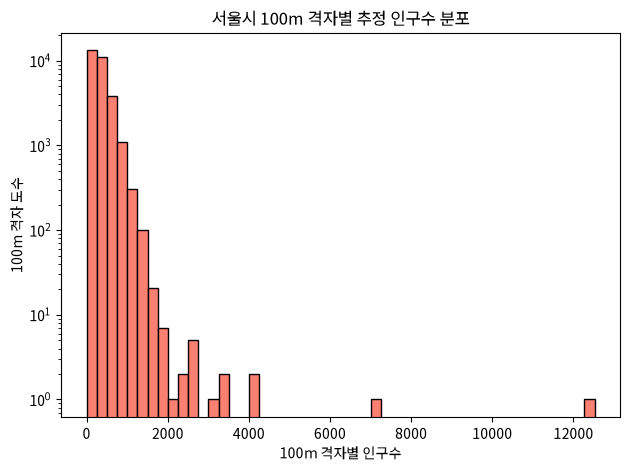

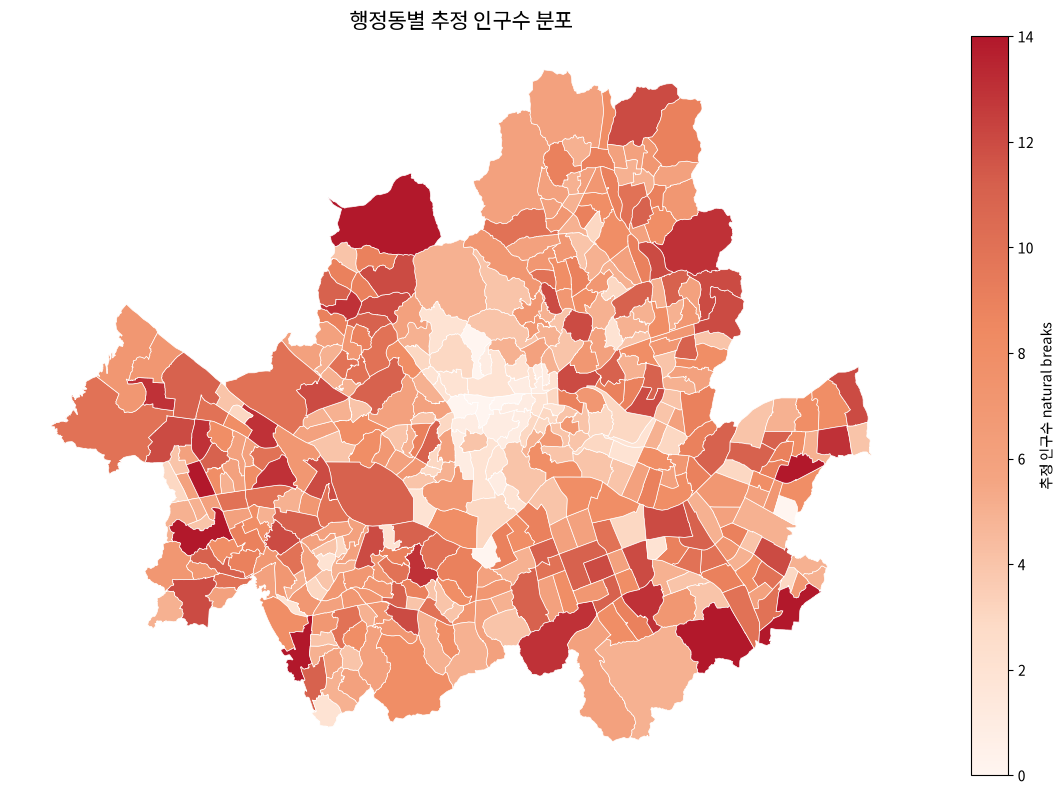

In [35]:
# 시각화
import mapclassify as mc

plot_grid = grid_population_final[grid_population_final["추정_인구수"] > 0]

# 인구 분포 히스토그램
plt.hist(
plot_grid["추정_인구수"],
color = 'salmon',
edgecolor = 'black',
bins = 50)
plt.title("서울시 100m 격자별 추정 인구수 분포", fontsize=12)
plt.ylabel("100m 격자 도수")
plt.xlabel("100m 격자별 인구수")
plt.yscale('log')
plt.tight_layout()
plt.savefig(IMAGE_PATH / "서울시_100m격자_추정인구수_분포.png",
            pad_inches = 0.1, 
            bbox_inches = 'tight',
            dpi = 240)
plt.show()


plot_hjd_pop = grid_population_final.groupby(
    "행정동코드",
    as_index=False
).agg({
    "추정_인구수": "sum",
    "시군구": "first",
    "행정동": "first"
})

# 코드 타입 맞추기
plot_hjd_pop["행정동코드"] = plot_hjd_pop["행정동코드"].astype(str)

hjd_plot_base = hjd_seoul.copy()
hjd_plot_base["ADM_CD"] = hjd_plot_base["ADM_CD"].astype(str)

# 행정동 경계에 추정인구 붙이기
plot_hjd = hjd_plot_base.merge(
    plot_hjd_pop,
    left_on="ADM_CD",
    right_on="행정동코드",
    how="left"
)

# Natural Break로 구간화 후 시각화
plot_hjd["추정_인구수_nb"] = mc.NaturalBreaks(plot_hjd['추정_인구수'], 
                                                   k = 15).yb

from matplotlib.colors import LinearSegmentedColormap

salmon_cmap = LinearSegmentedColormap.from_list(
    "salmon_cmap",
    ["#fff5f0", "#fddbc7", "#f4a582", "#ef8a62", "#d6604d", "#b2182b"]
)

fig, ax = plt.subplots(figsize=(12, 8))

plot_hjd.plot(
    ax=ax,
    column="추정_인구수_nb",
    cmap=salmon_cmap,
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    legend_kwds={"label": "추정 인구수 natural breaks"}
)
ax.set_title("행정동별 추정 인구수 분포", fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(IMAGE_PATH / "서울시_행정동_추정인구수_분포.png",
            pad_inches = 0.1, 
            bbox_inches = 'tight',
            dpi = 240)
plt.show()


grid_population_final.to_file(MAKING_TABLE_PATH / "서울시_100m_추정인구.gpkg",
                              driver = "GPKG")


In [80]:
print(f'서울 실제 인구수 합 - 추정 인구수 합: {hjd_est_compare["행정동별_인구수"].sum(axis=0) - grid_est_pop["추정_인구수"].sum(axis=0)}')

pop_error = hjd_est_compare.copy()

# -4837.0

pop_error["인구차이"] = pop_error["행정동별_인구수"] - pop_error["추정인구수4"]


pop_error[["시군구", "행정동", "인구차이"]].sort_values(by="인구차이")
display(
    pop_error[(pop_error["행정동"] == '오륜동') | 
          (pop_error["행정동"] == '성내3동') |
          (pop_error["행정동"] == '둔촌2동')]
)


dunchon_idx = (grid_est_pop["시군구"] == "강동구") & (grid_est_pop["행정동"] == '둔촌1동')
dunchon_pop = grid_est_pop[dunchon_idx]
print(f'둔촌동 GRID 100 원본 인구수 합: {dunchon_pop["원본_인구수"].sum()}')
print(f'둔촌동 GRID 100 주거면적 합: {dunchon_pop["주거면적"].sum()}')
print(f'둔촌동 GRID 100 주택수 합: {dunchon_pop["주택수"].sum()}')

samsung_idx = (grid_est_pop["시군구"] == "강남구") & (grid_est_pop["행정동"] == '삼성1동')
samsung_pop = grid_est_pop[samsung_idx]
print(f'\n삼성1동 GRID 100 원본 인구수 합: {samsung_pop["원본_인구수"].sum()}')
print(f'삼성1동 GRID 100 주거면적 합: {samsung_pop["주거면적"].sum()}')
print(f'삼성1동 GRID 100 주택수 합: {samsung_pop["주택수"].sum()}')



서울 실제 인구수 합 - 추정 인구수 합: -4837.0


,시군구,행정동별_인구수,행정동,추정인구수1,추정인구수2,추정인구수3,추정인구수4,인구차이
27,강동구,24694,둔촌2동,23563.860837,23562.349576,23561.342069,23561.791797,1132.208203
34,강동구,21777,성내3동,21789.963532,21789.962086,21789.961122,21789.946454,-12.946454
299,송파구,17575,오륜동,18039.000000,18039.000000,18039.000000,18039.000000,-464.000000


둔촌동 GRID 100 원본 인구수 합: 352.0
둔촌동 GRID 100 주거면적 합: 344.84999999999997
둔촌동 GRID 100 주택수 합: 98.0

삼성1동 GRID 100 원본 인구수 합: 12170.0
삼성1동 GRID 100 주거면적 합: 17243.76
삼성1동 GRID 100 주택수 합: 4041.0
